# Library

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import randint, uniform
import shap

c:\skripsi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train = pd.read_csv('C:/skripsi/rev6_apr/data_ori/train_ori_6apr.csv')
df_test  = pd.read_csv('C:/skripsi/rev6_apr/data_ori/test_ori_6apr.csv')

In [3]:
kecamatan_dummies_train = pd.get_dummies(
    df_train['kecamatan'], 
    prefix='kecamatan'
).astype(int)

df_train = pd.concat(
    [df_train.drop('kecamatan', axis=1), kecamatan_dummies_train],
    axis=1
)

kecamatan_dummies_test = pd.get_dummies(
    df_test['kecamatan'], 
    prefix='kecamatan'
).astype(int)

# Samakan kolom dummy test dengan train
kecamatan_dummies_test = kecamatan_dummies_test.reindex(
    columns=kecamatan_dummies_train.columns,
    fill_value=0
)

df_test = pd.concat(
    [df_test.drop('kecamatan', axis=1), kecamatan_dummies_test],
    axis=1
)

display(df_train.head())

,Harga_Asli,bedroom,bathrooms,jumlah_guest_toilet,lantai,area_digunakan,luas_tanah,latitude,longitude,dist_SD,...,kecamatan_Prambon,kecamatan_Sedati,kecamatan_Sidoarjo,kecamatan_Sukodono,kecamatan_Taman,kecamatan_Tanggulangin,kecamatan_Tarik,kecamatan_Tulangan,kecamatan_Waru,kecamatan_Wonoayu
0,67.5,3,1,0,1,91,91,-7.391772,112.730670,0.811599,...,0,0,0,0,0,0,0,0,0,0
1,135.0,4,3,0,1,204,102,-7.526800,112.663700,7.897964,...,0,0,0,0,0,0,0,0,0,0
2,63.1,3,3,3,1,80,90,-7.481293,112.646861,6.327984,...,0,0,0,0,0,0,0,1,0,0
3,38.5,2,1,0,1,100,60,-7.394061,112.673881,0.841155,...,0,0,0,1,0,0,0,0,0,0
4,70.0,2,1,0,2,140,179,-7.451411,112.687169,1.270364,...,0,0,1,0,0,0,0,0,0,0


In [4]:
import warnings
warnings.filterwarnings('ignore')

class ZScoreTransformer:
    """Custom Z-Score Transformer untuk standardisasi target."""
    def __init__(self):
        self.fitted = False
        self.mean_ = None
        self.std_ = None
    
    def fit(self, X):
        """Hitung mean dan standar deviasi dari data train."""
        arr = np.asarray(X, dtype=float).reshape(-1, 1)
        self.mean_ = float(np.mean(arr))
        self.std_ = float(np.std(arr, ddof=0))
        if self.std_ == 0:
            self.std_ = 1.0
        self.fitted = True
        return self
    
    def transform(self, X):
        """Apply standardisasi z-score."""
        if not self.fitted:
            raise ValueError("Transformer harus di-fit terlebih dahulu.")
        arr = np.asarray(X, dtype=float).reshape(-1, 1)
        return (arr - self.mean_) / self.std_
    
    def fit_transform(self, X):
        """Fit lalu transform dalam satu langkah."""
        self.fit(X)
        return self.transform(X)
    
    def inverse_transform(self, X):
        """Kembalikan data ke skala asli."""
        if not self.fitted:
            raise ValueError("Transformer harus di-fit terlebih dahulu.")
        arr = np.asarray(X, dtype=float).reshape(-1, 1)
        return (arr * self.std_) + self.mean_

num_cols = ['Harga_Asli']
fitted_transformers = {}

train_df_transformed = df_train.copy()
val_df_transformed = df_test.copy()

for col in num_cols:
    zscore_transformer = ZScoreTransformer()
    
    train_values = train_df_transformed[col].values.reshape(-1, 1)
    val_values = val_df_transformed[col].values.reshape(-1, 1)
    
    zscore_transformer.fit(train_values)
    
    train_df_transformed[col] = zscore_transformer.transform(train_values)
    val_df_transformed[col] = zscore_transformer.transform(val_values)
    
    fitted_transformers[col.lower()] = zscore_transformer

display(train_df_transformed.head())
display(val_df_transformed.head())

,Harga_Asli,bedroom,bathrooms,jumlah_guest_toilet,lantai,area_digunakan,luas_tanah,latitude,longitude,dist_SD,...,kecamatan_Prambon,kecamatan_Sedati,kecamatan_Sidoarjo,kecamatan_Sukodono,kecamatan_Taman,kecamatan_Tanggulangin,kecamatan_Tarik,kecamatan_Tulangan,kecamatan_Waru,kecamatan_Wonoayu
0,-0.186808,3,1,0,1,91,91,-7.391772,112.730670,0.811599,...,0,0,0,0,0,0,0,0,0,0
1,1.402383,4,3,0,1,204,102,-7.526800,112.663700,7.897964,...,0,0,0,0,0,0,0,0,0,0
2,-0.290400,3,3,3,1,80,90,-7.481293,112.646861,6.327984,...,0,0,0,0,0,0,0,1,0,0
3,-0.869572,2,1,0,1,100,60,-7.394061,112.673881,0.841155,...,0,0,0,1,0,0,0,0,0,0
4,-0.127949,2,1,0,2,140,179,-7.451411,112.687169,1.270364,...,0,0,1,0,0,0,0,0,0,0


,Harga_Asli,bedroom,bathrooms,jumlah_guest_toilet,lantai,area_digunakan,luas_tanah,latitude,longitude,dist_SD,...,kecamatan_Prambon,kecamatan_Sedati,kecamatan_Sidoarjo,kecamatan_Sukodono,kecamatan_Taman,kecamatan_Tanggulangin,kecamatan_Tarik,kecamatan_Tulangan,kecamatan_Waru,kecamatan_Wonoayu
0,-0.611110,2,1,1,1,37,72,-7.472613,112.667540,3.788485,...,0,0,0,0,0,0,0,1,0,0
1,-0.645908,2,1,1,1,65,120,-7.449034,112.569756,7.138616,...,1,0,0,0,0,0,0,0,0,0
2,-0.857800,2,1,0,1,40,90,-7.371738,112.763734,1.055520,...,0,1,0,0,0,0,0,0,0,0
3,-0.598820,2,1,0,1,160,91,-7.425129,112.723091,1.910300,...,0,0,0,0,0,0,0,0,0,0
4,1.543644,3,2,2,2,73,73,-7.378482,112.736588,2.876396,...,0,0,0,0,0,0,0,0,0,0


In [5]:
shape_ori = train_df_transformed.copy()

# Modelling

## XGBoost

In [6]:
y_train_XB = train_df_transformed["Harga_Asli"]
X_train_XB = train_df_transformed.drop(columns=["Harga_Asli","latitude", "longitude"])

y_test_XB = val_df_transformed["Harga_Asli"]
X_test_XB = val_df_transformed.drop(columns=["Harga_Asli","latitude", "longitude"])

In [7]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    device="cpu",
    eval_metric="rmse",
    max_bin=512,
    n_jobs=1,
    verbosity=0
)

param_dist = {
    "n_estimators": randint(300, 800),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2)
}


In [8]:
cv = KFold(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    error_score="raise"
)

random_search.fit(
    X_train_XB,
    y_train_XB
)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   0.3s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   0.3s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_estimators=402, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.7836995567863468; total time=   0.4s
[CV] END colsample_bytree=0.749816047538945, gamma=4.75357153204958, learning_rate=0.15639878836228102, max_depth=7, min_child_weight=5, n_e

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   error_score='raise',
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cpu',
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric='rmse',
                                          feature_types=None,
                                          feature_weights=None,...
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001421E8DD950>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001421E8AC310>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001421C69D6D0>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [9]:
best_model = random_search.best_estimator_
best_model_xgb = best_model

print("Best Params:")
print(random_search.best_params_)

Best Params:
{'colsample_bytree': 0.6733618039413735, 'gamma': 1.5212112147976886, 'learning_rate': 0.11495128632644756, 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 348, 'reg_alpha': 0.5247746602583891, 'reg_lambda': 1.299721943430511, 'subsample': 0.6186662652854461}


In [51]:
# Evaluasi train vs test - XGBoost
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prediksi pada skala transformasi
y_pred_train_xgb = best_model_xgb.predict(X_train_XB)
y_pred_test_xgb = best_model_xgb.predict(X_test_XB)

# Kembalikan ke skala harga asli
zscaler = fitted_transformers['harga_asli']
y_train_orig = zscaler.inverse_transform(y_train_XB.values.reshape(-1, 1)).ravel()
y_test_orig = zscaler.inverse_transform(y_test_XB.values.reshape(-1, 1)).ravel()
y_pred_train_orig = zscaler.inverse_transform(y_pred_train_xgb.reshape(-1, 1)).ravel()
y_pred_test_orig = zscaler.inverse_transform(y_pred_test_xgb.reshape(-1, 1)).ravel()

def regression_report(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

xgb_train_metrics = regression_report(y_train_orig, y_pred_train_orig)
xgb_test_metrics = regression_report(y_test_orig, y_pred_test_orig)

xgb_eval = pd.DataFrame([xgb_train_metrics, xgb_test_metrics], index=["Train", "Test"])
print("XGBoost Evaluation (Harga Asli)")
display(xgb_eval)

# Perbandingan prediksi vs aktual (test set)
comparison_df_xgb = pd.DataFrame({
    'Harga Aktual': y_test_orig.flatten(),
    'Harga Prediksi': y_pred_test_orig.flatten(),
    'Selisih (Absolut)': np.abs(y_test_orig.flatten() - y_pred_test_orig.flatten())
})

pd.options.display.float_format = 'Rp {:,.2f}'.format
print("Perbandingan Prediksi vs Aktual - XGBoost (Test, Skala Asli)")
display(comparison_df_xgb.head(10))

XGBoost Evaluation (Harga Asli)


,R2,MSE,RMSE,MAE
Train,0.745162,459.748056,21.441736,15.429413
Test,0.671444,733.198357,27.077636,19.550292


Perbandingan Prediksi vs Aktual - XGBoost (Test, Skala Asli)


,Harga Aktual,Harga Prediksi,Selisih (Absolut)
0,Rp 49.48,Rp 40.49,Rp 8.99
1,Rp 48.00,Rp 42.49,Rp 5.51
2,Rp 39.00,Rp 58.48,Rp 19.48
3,Rp 50.00,Rp 45.26,Rp 4.74
4,Rp 141.00,Rp 90.55,Rp 50.45
5,Rp 150.00,Rp 58.60,Rp 91.40
6,Rp 15.00,Rp 46.54,Rp 31.54
7,Rp 190.00,Rp 113.05,Rp 76.95
8,Rp 40.00,Rp 40.00,Rp 0.00
9,Rp 58.50,Rp 51.51,Rp 6.99


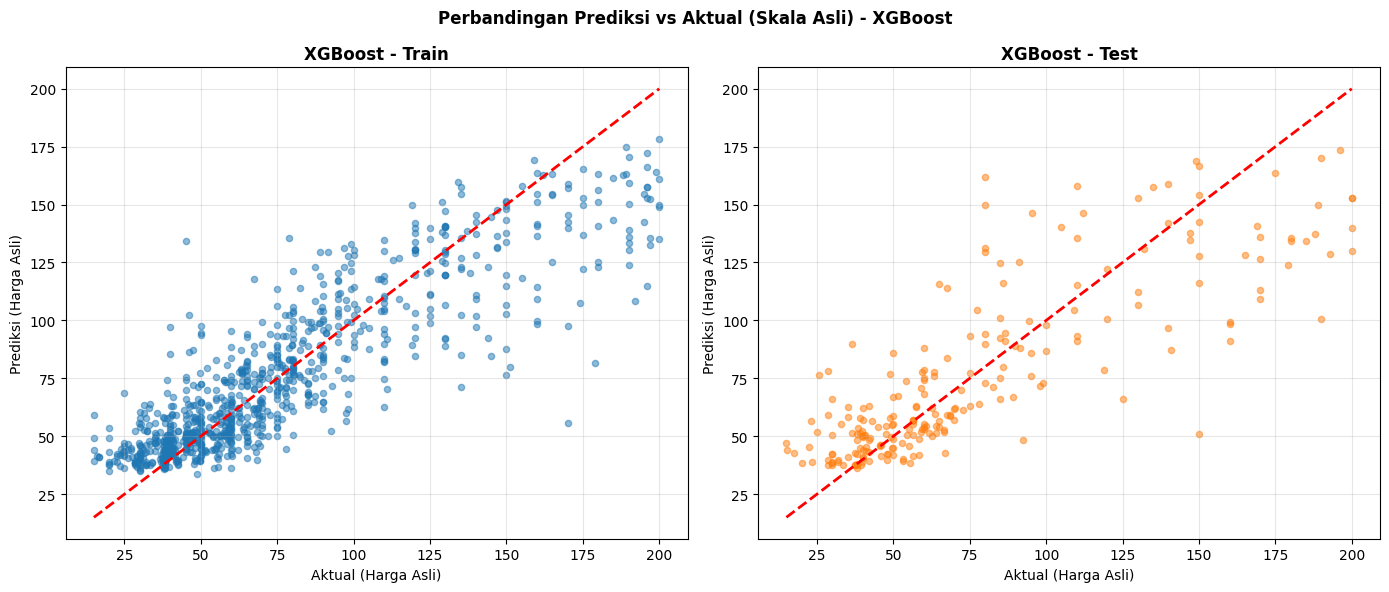

In [11]:
# Perbandingan Prediksi vs Aktual (Skala Asli) - XGBoost
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train plot
axes[0].scatter(y_train_orig, y_pred_train_orig, alpha=0.5, s=20, color='#1f77b4')
min_train = min(y_train_orig.min(), y_pred_train_orig.min())
max_train = max(y_train_orig.max(), y_pred_train_orig.max())
axes[0].plot([min_train, max_train], [min_train, max_train], 'r--', linewidth=2)
axes[0].set_title('XGBoost - Train', fontweight='bold')
axes[0].set_xlabel('Aktual (Harga Asli)')
axes[0].set_ylabel('Prediksi (Harga Asli)')
axes[0].grid(alpha=0.3)

# Test plot
axes[1].scatter(y_test_orig, y_pred_test_orig, alpha=0.5, s=20, color='#ff7f0e')
min_test = min(y_test_orig.min(), y_pred_test_orig.min())
max_test = max(y_test_orig.max(), y_pred_test_orig.max())
axes[1].plot([min_test, max_test], [min_test, max_test], 'r--', linewidth=2)
axes[1].set_title('XGBoost - Test', fontweight='bold')
axes[1].set_xlabel('Aktual (Harga Asli)')
axes[1].set_ylabel('Prediksi (Harga Asli)')
axes[1].grid(alpha=0.3)

plt.suptitle('Perbandingan Prediksi vs Aktual (Skala Asli) - XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

cv_results = []

for train_idx, test_idx in cv.split(X_train_XB, y_train_XB):
    
    X_train_fold, X_test = X_train_XB.iloc[train_idx], X_train_XB.iloc[test_idx]
    y_train_fold, y_test = y_train_XB.iloc[train_idx], y_train_XB.iloc[test_idx]

    model = best_model
    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict(X_test)

    # Hitung metrik global
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cv_results.append({
        'R2': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    })

# Buat DataFrame hasil evaluasi
eval_df = pd.DataFrame(cv_results)

print("CV Results (Global):")
print(eval_df)


CV Results (Global):
         R2       MSE      RMSE       MAE
0  0.575563  0.418234  0.646710  0.455693
1  0.610065  0.402694  0.634582  0.429545
2  0.561139  0.447588  0.669020  0.467791
3  0.579493  0.444152  0.666447  0.488323
4  0.580886  0.376666  0.613731  0.436249


In [13]:
cv_summary = pd.DataFrame({
    "R2_mean": [eval_df["R2"].mean()],
    "R2_std": [eval_df["R2"].std()],
    "MSE_mean": [eval_df["MSE"].mean()],
    "MSE_std": [eval_df["MSE"].std()],
    "RMSE_mean": [eval_df["RMSE"].mean()],
    "RMSE_std": [eval_df["RMSE"].std()],
    "MAE_mean": [eval_df["MAE"].mean()],
    "MAE_std": [eval_df["MAE"].std()]
})

print("="*60)
print("CROSS-VALIDATION SUMMARY (GLOBAL)")
print("="*60)
print(cv_summary.to_string(index=False))


CROSS-VALIDATION SUMMARY (GLOBAL)
 R2_mean  R2_std  MSE_mean  MSE_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
0.581429 0.01782  0.417867 0.029589   0.646098  0.023022   0.45552 0.023837


In [14]:
importance = pd.DataFrame({
    "feature": X_train_XB.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

                     feature  importance
1                  bathrooms    0.146988
0                    bedroom    0.135961
15             dist_Terminal    0.056836
89        kecamatan_Sidoarjo    0.028733
29              Fully fenced    0.028684
16              dist_Bandara    0.023421
91           kecamatan_Taman    0.023093
3                     lantai    0.021516
22                       Air    0.021026
95            kecamatan_Waru    0.020901
30                    Garasi    0.020761
7                   dist_SMP    0.020613
10  dist_Fasilitas_Kesehatan    0.020435
14              dist_Stasiun    0.020077
78                 Tidak Ada    0.019226
12          dist_Supermarket    0.019044
4             area_digunakan    0.019015
34                  Internet    0.018945
18       dist_Entry_Exit_Tol    0.017972
57                      Wifi    0.017874


In [15]:
#importance.to_csv('C:/skripsi/rev6_apr/rev_code/fitur2/1_feature_importance_XGB.csv', index=False)

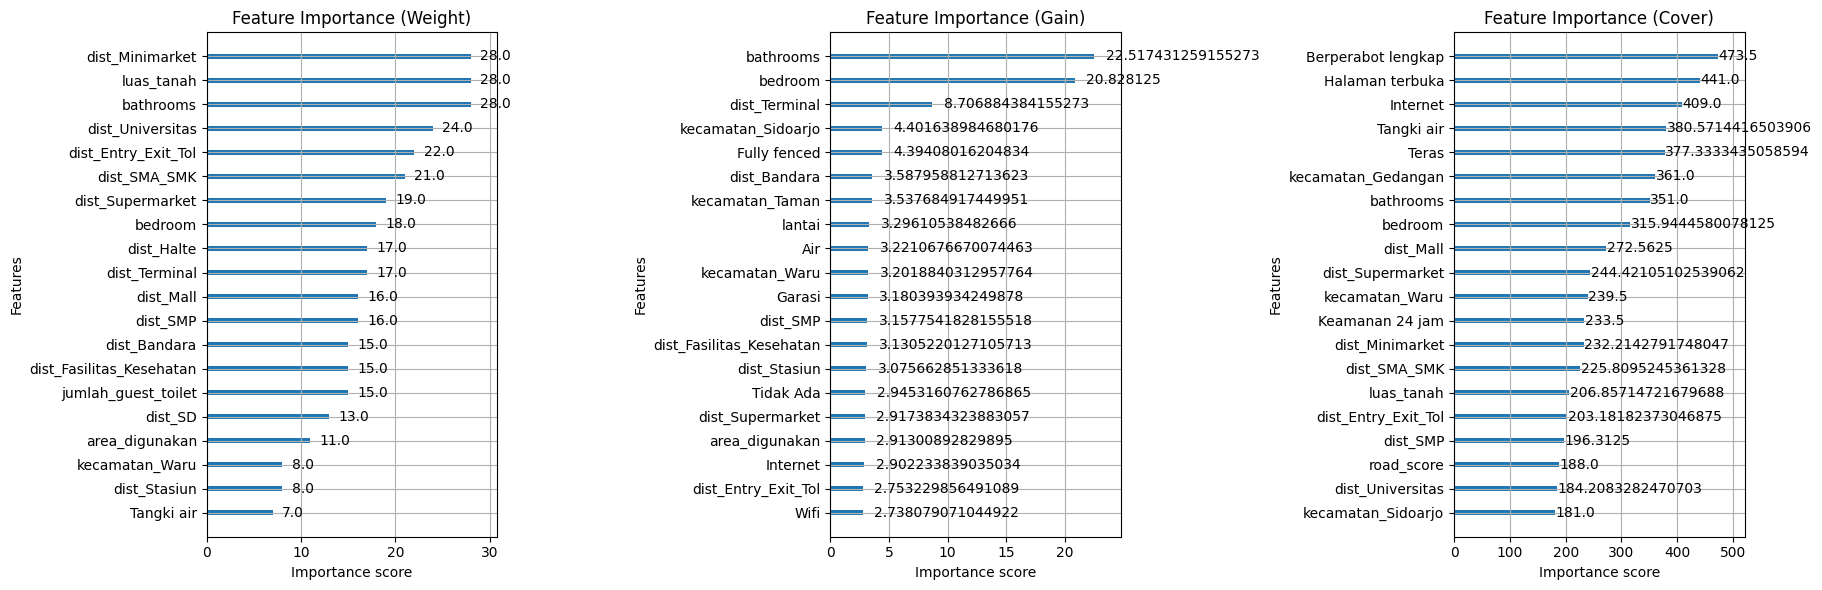


Top 20 Features (Average of Weight, Gain, Cover):
                feature  importance_weight  importance_gain  importance_cover  \
2    Berperabot lengkap                2.0         1.681101        473.500000   
7       Halaman terbuka                2.0         1.689078        441.000000   
8              Internet                1.0         2.902234        409.000000   
17            bathrooms               28.0        22.517431        351.000000   
11           Tangki air                7.0         1.978002        380.571442   
13                Teras                3.0         1.612449        377.333344   
33   kecamatan_Gedangan                2.0         2.368397        361.000000   
18              bedroom               18.0        20.828125        315.944458   
23            dist_Mall               16.0         2.518118        272.562500   
29     dist_Supermarket               19.0         2.917383        244.421051   
24      dist_Minimarket               28.0         2.28958

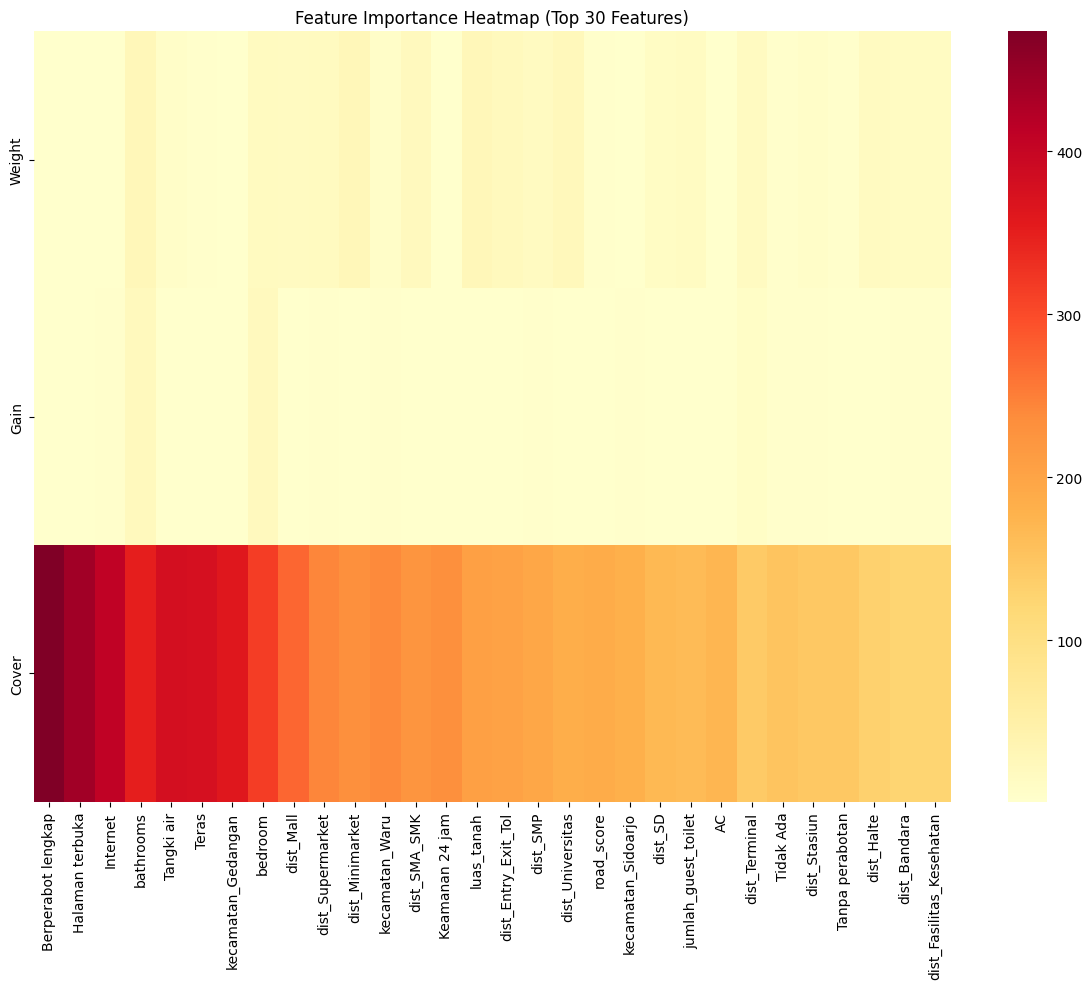

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance

# Method 1: XGBoost plot_importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Weight importance
plot_importance(best_model, importance_type='weight', max_num_features=20, ax=axes[0])
axes[0].set_title('Feature Importance (Weight)')

# Gain importance
plot_importance(best_model, importance_type='gain', max_num_features=20, ax=axes[1])
axes[1].set_title('Feature Importance (Gain)')

# Cover importance
plot_importance(best_model, importance_type='cover', max_num_features=20, ax=axes[2])
axes[2].set_title('Feature Importance (Cover)')

plt.tight_layout()
plt.show()

# Method 2: Custom DataFrame Analysis
importance_types = ['weight', 'gain', 'cover']
importance_df = pd.DataFrame()

for imp_type in importance_types:
    booster = best_model.get_booster()
    importance_dict = booster.get_score(importance_type=imp_type)
    temp_df = pd.DataFrame({
        'feature': list(importance_dict.keys()),
        f'importance_{imp_type}': list(importance_dict.values())
    })
    if importance_df.empty:
        importance_df = temp_df
    else:
        importance_df = importance_df.merge(temp_df, on='feature', how='outer')

importance_df = importance_df.fillna(0)
importance_df['avg_importance'] = importance_df[[f'importance_{t}' for t in importance_types]].mean(axis=1)
importance_df = importance_df.sort_values('avg_importance', ascending=False)

print("\nTop 20 Features (Average of Weight, Gain, Cover):")
print(importance_df.head(20))

# Heatmap
plt.figure(figsize=(12, 10))
top_features = importance_df.head(30)
heatmap_data = top_features[[f'importance_{t}' for t in importance_types]].T
sns.heatmap(heatmap_data, 
            xticklabels=top_features['feature'],
            yticklabels=['Weight', 'Gain', 'Cover'],
            cmap='YlOrRd',
            annot=False,
            fmt='.2f')
plt.title('Feature Importance Heatmap (Top 30 Features)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
#importance_df.to_csv('C:/skripsi/rev6_apr/rev_code/fitur2/2_feature_importance_XGB_detailed.csv', index=False)

### SHAP

In [18]:
# SHAP Analysis untuk XGBoost
# Solusi FINAL: Menggunakan numpy array dan xgboost.Booster untuk menghindari semua error

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SHAP ANALYSIS - XGBOOST MODEL")
print("="*80)

# Ambil skala asli target agar semua output SHAP kembali ke rupiah asli
target_transformer = fitted_transformers['harga_asli']
target_mean = float(target_transformer.mean_)
target_std = float(target_transformer.std_)

# Step 1: Ambil sample data untuk efisiensi komputasi
print("\n[1/6] Preparing data for SHAP analysis...")
n_samples = min(1000, len(X_train_XB))
sample_indices = X_train_XB.sample(n_samples, random_state=42).index
X_shap_sample = X_train_XB.loc[sample_indices].copy()
y_shap_sample = y_train_XB.loc[sample_indices].copy()

# Simpan nama kolom untuk nanti
feature_names = X_shap_sample.columns.tolist()

# Convert ke numpy array (menghindari masalah feature_names_in_)
X_shap_np = X_shap_sample.values
y_shap_np = y_shap_sample.values

# Konversi target dan hasil SHAP ke skala asli
X_shap_target_original = y_shap_np * target_std + target_mean

print(f"   Sample size: {X_shap_np.shape}")
print(f"   Features: {len(feature_names)}")

# Step 2: Buat model baru dengan sklearn-compatible approach
print("\n[2/6] Creating fresh XGBoost model for SHAP...")
best_params = random_search.best_params_.copy()

# Buat model tanpa feature names (pure numpy)
import xgboost as xgb

# Gunakan DMatrix untuk kontrol penuh
dtrain = xgb.DMatrix(X_shap_np, label=y_shap_np, feature_names=feature_names)

# Parameter untuk training
xgb_params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'max_depth': best_params.get('max_depth', 4),
    'learning_rate': best_params.get('learning_rate', 0.01),
    'subsample': best_params.get('subsample', 0.7),
    'colsample_bytree': best_params.get('colsample_bytree', 0.7),
    'min_child_weight': best_params.get('min_child_weight', 2),
    'gamma': best_params.get('gamma', 3),
    'reg_alpha': best_params.get('reg_alpha', 0.4),
    'reg_lambda': best_params.get('reg_lambda', 2.5),
    'seed': 42,
    'verbosity': 0
}

n_estimators = best_params.get('n_estimators', 500)
print(f"   Params: max_depth={xgb_params['max_depth']}, n_estimators={n_estimators}")

# Step 3: Train model
print("\n[3/6] Training XGBoost model...")
booster = xgb.train(xgb_params, dtrain, num_boost_round=n_estimators)
print("   ✓ Model trained successfully")

# Step 4: Verify model performance
print("\n[4/6] Verifying model performance...")
train_pred = booster.predict(dtrain)
train_pred_original = train_pred * target_std + target_mean
train_rmse = np.sqrt(mean_squared_error(X_shap_target_original, train_pred_original))
train_mae = mean_absolute_error(X_shap_target_original, train_pred_original)
print(f"   RMSE: Rp {train_rmse:,.0f}")
print(f"   MAE: Rp {train_mae:,.0f}")

# Step 5: Create SHAP explainer dengan Booster
print("\n[5/6] Creating SHAP TreeExplainer...")
shap_success = False
shap_values = None
explainer = None
expected_value = None

try:
    
    # Method: Gunakan TreeExplainer dengan booster langsung
    explainer = shap.TreeExplainer(booster)
    expected_value = explainer.expected_value
    print("   ✓ TreeExplainer created successfully")
    shap_success = True
except Exception as e:
    print(f"   ✗ TreeExplainer failed: {str(e)[:100]}")
    
    # Fallback: Gunakan predict function untuk KernelExplainer
    try:
        print("   Trying KernelExplainer with predict function...")
        
        def predict_fn(X):
            dmatrix = xgb.DMatrix(X, feature_names=feature_names)
            return booster.predict(dmatrix)
        
        background = X_shap_np[np.random.choice(len(X_shap_np), min(100, len(X_shap_np)), replace=False)]
        explainer = shap.KernelExplainer(predict_fn, background)
        expected_value = explainer.expected_value
        print("   ✓ KernelExplainer created successfully")
        shap_success = True
    except Exception as e2:
        print(f"   ✗ KernelExplainer failed: {str(e2)[:100]}")

# Step 6: Calculate SHAP values
if shap_success and explainer is not None:
    print("\n[6/6] Calculating SHAP values...")
    try:
        if isinstance(explainer, shap.TreeExplainer):
            shap_values = explainer.shap_values(dtrain)
        else:
            # KernelExplainer
            shap_values = explainer.shap_values(X_shap_np, nsamples=100, silent=True)
        
        shap_values_original = shap_values * target_std
        expected_value_original = float(expected_value) * target_std + target_mean
        
        print(f"   ✓ SHAP values calculated!")
        print(f"   Shape: {shap_values_original.shape}")
        print(f"   Base value: Rp {expected_value_original:,.0f}")
        print("\n" + "="*80)
        print("✓ SHAP ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
    except Exception as e:
        print(f"\n   ✗ Failed to calculate SHAP values: {e}")
        shap_success = False
        shap_values = None
        shap_values_original = None
        expected_value_original = None
else:
    print("\n" + "="*80)
    print("✗ SHAP ANALYSIS FAILED - Using Permutation Importance instead")
    print("="*80)
    shap_values = None
    shap_values_original = None
    expected_value_original = None
    train_pred_original = None


SHAP ANALYSIS - XGBOOST MODEL

[1/6] Preparing data for SHAP analysis...
   Sample size: (916, 97)
   Features: 97

[2/6] Creating fresh XGBoost model for SHAP...
   Params: max_depth=6, n_estimators=348

[3/6] Training XGBoost model...
   ✓ Model trained successfully

[4/6] Verifying model performance...
   RMSE: Rp 21
   MAE: Rp 15

[5/6] Creating SHAP TreeExplainer...
   ✗ TreeExplainer failed: could not convert string to float: '[7.295021E-10]'
   Trying KernelExplainer with predict function...
   ✓ KernelExplainer created successfully

[6/6] Calculating SHAP values...
   ✓ SHAP values calculated!
   Shape: (916, 97)
   Base value: Rp 74

✓ SHAP ANALYSIS COMPLETED SUCCESSFULLY!


In [19]:
# Summary Statistics SHAP Values
if shap_values_original is not None:
    print("="*80)
    print("SHAP ANALYSIS SUMMARY")
    print("="*80)

    shap_summary = pd.DataFrame({
        'Feature': feature_names,
        'Mean_|SHAP|': np.abs(shap_values_original).mean(axis=0),
        'Std_SHAP': np.abs(shap_values_original).std(axis=0),
        'Max_|SHAP|': np.abs(shap_values_original).max(axis=0),
        'Mean_SHAP': shap_values_original.mean(axis=0)
    }).sort_values('Mean_|SHAP|', ascending=False)

    print("\nTop 20 Features by Mean Absolute SHAP Value:")
    print(shap_summary.head(20).to_string(index=False))

    print("\n" + "="*80)
    print(f"Model Base Value (Expected): Rp {float(expected_value_original):,.0f}")
    print(f"Mean Prediction: Rp {train_pred_original.mean():,.0f}")
    print(f"Actual Mean Price: Rp {X_shap_target_original.mean():,.0f}")
    print("="*80)
else:
    print("⚠ SHAP values not available. Skipping summary.")


SHAP ANALYSIS SUMMARY

Top 20 Features by Mean Absolute SHAP Value:
                 Feature  Mean_|SHAP|  Std_SHAP  Max_|SHAP|  Mean_SHAP
               bathrooms    10.978243  9.665657   48.124089   2.014285
                 bedroom     6.428371  3.852197   21.397606   0.304968
            dist_Bandara     1.950964  2.226708   11.039717  -0.182013
          kecamatan_Waru     1.445618  2.597804   13.762947   0.613616
        dist_Supermarket     1.208689  2.186173   12.233952  -0.091255
     jumlah_guest_toilet     1.067753  1.586953    6.730964  -0.433147
           dist_Terminal     0.973020  1.836818    9.896751   0.022594
               dist_Mall     0.836025  2.270506   16.532591   0.297144
        dist_Universitas     0.668448  2.014482   14.697325   0.342566
         dist_Minimarket     0.532262  1.439355    8.745458  -0.067570
            dist_SMA_SMK     0.524840  1.115203    6.681012  -0.208923
              luas_tanah     0.443292  1.391353    8.963881  -0.264862
         

In [20]:
# Export SHAP values untuk analisis lebih lanjut
if shap_values_original is not None:
    shap_df = pd.DataFrame(
        shap_values_original,
        columns=[f'shap_{col}' for col in feature_names]
    )

    # Gabung dengan data asli
    shap_analysis_df = pd.concat([
        X_shap_sample.reset_index(drop=True),
        shap_df.reset_index(drop=True),
        pd.Series(X_shap_target_original, name='actual_price')
    ], axis=1)

    # Tambahkan prediksi
    shap_analysis_df['predicted_price'] = train_pred_original
    shap_analysis_df['prediction_error'] = shap_analysis_df['actual_price'] - shap_analysis_df['predicted_price']

    print("SHAP Analysis DataFrame:")
    print(shap_analysis_df.head())
    print(f"\nShape: {shap_analysis_df.shape}")
else:
    print("⚠ SHAP values not available. Skipping export.")


SHAP Analysis DataFrame:
   bedroom  bathrooms  jumlah_guest_toilet  lantai  area_digunakan  \
0        3          1                    0       1             100   
1        5          3                    0       1             125   
2        3          2                    0       1             140   
3        2          1                    1       1              45   
4        3          2                    1       1              84   

   luas_tanah   dist_SD  dist_SMP  dist_SMA_SMK  dist_Universitas  ...  \
0         118  0.158767  1.777258      1.211823          4.456698  ...   
1         120  1.588239  1.491888      1.870270          2.465939  ...   
2         120  1.329266  1.199338      1.227778          0.816918  ...   
3          78  1.126267  0.584706      0.871008          1.730460  ...   
4          84  3.655698  4.153967      4.333047          2.145324  ...   

   shap_kecamatan_Sukodono  shap_kecamatan_Taman  shap_kecamatan_Tanggulangin  \
0                      0.0  

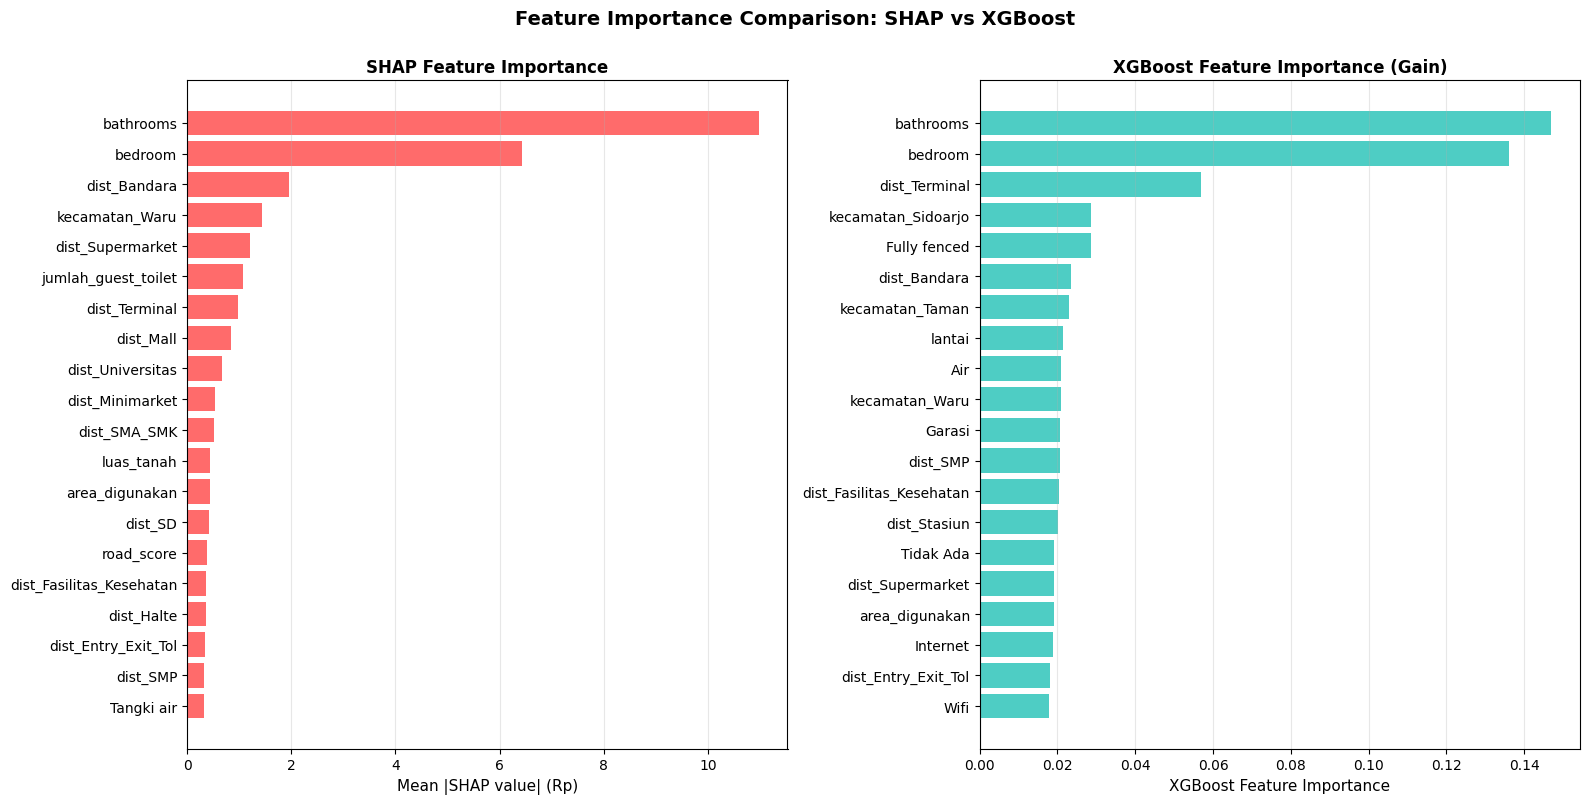

In [21]:
# SHAP Feature Importance Comparison dengan XGBoost Feature Importance
if shap_values_original is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # SHAP Importance
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': np.abs(shap_values_original).mean(axis=0)
    }).sort_values('shap_importance', ascending=True).tail(20)

    axes[0].barh(range(len(shap_importance)), shap_importance['shap_importance'], color='#FF6B6B')
    axes[0].set_yticks(range(len(shap_importance)))
    axes[0].set_yticklabels(shap_importance['feature'])
    axes[0].set_xlabel('Mean |SHAP value| (Rp)', fontsize=11)
    axes[0].set_title('SHAP Feature Importance', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # XGBoost Importance (Gain)
    xgb_importance = pd.DataFrame({
        'feature': X_train_XB.columns,
        'xgb_importance': best_model.feature_importances_
    }).sort_values('xgb_importance', ascending=True).tail(20)

    axes[1].barh(range(len(xgb_importance)), xgb_importance['xgb_importance'], color='#4ECDC4')
    axes[1].set_yticks(range(len(xgb_importance)))
    axes[1].set_yticklabels(xgb_importance['feature'])
    axes[1].set_xlabel('XGBoost Feature Importance', fontsize=11)
    axes[1].set_title('XGBoost Feature Importance (Gain)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Feature Importance Comparison: SHAP vs XGBoost', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping comparison plot.")


In [22]:
all_shap_importance = pd.DataFrame({
    'feature': feature_names,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=True)

In [23]:
#all_shap_importance.to_csv('C:/skripsi/rev6_apr/rev_code/fitur2/3_feature_importance_SHAP_final.csv', index=False)

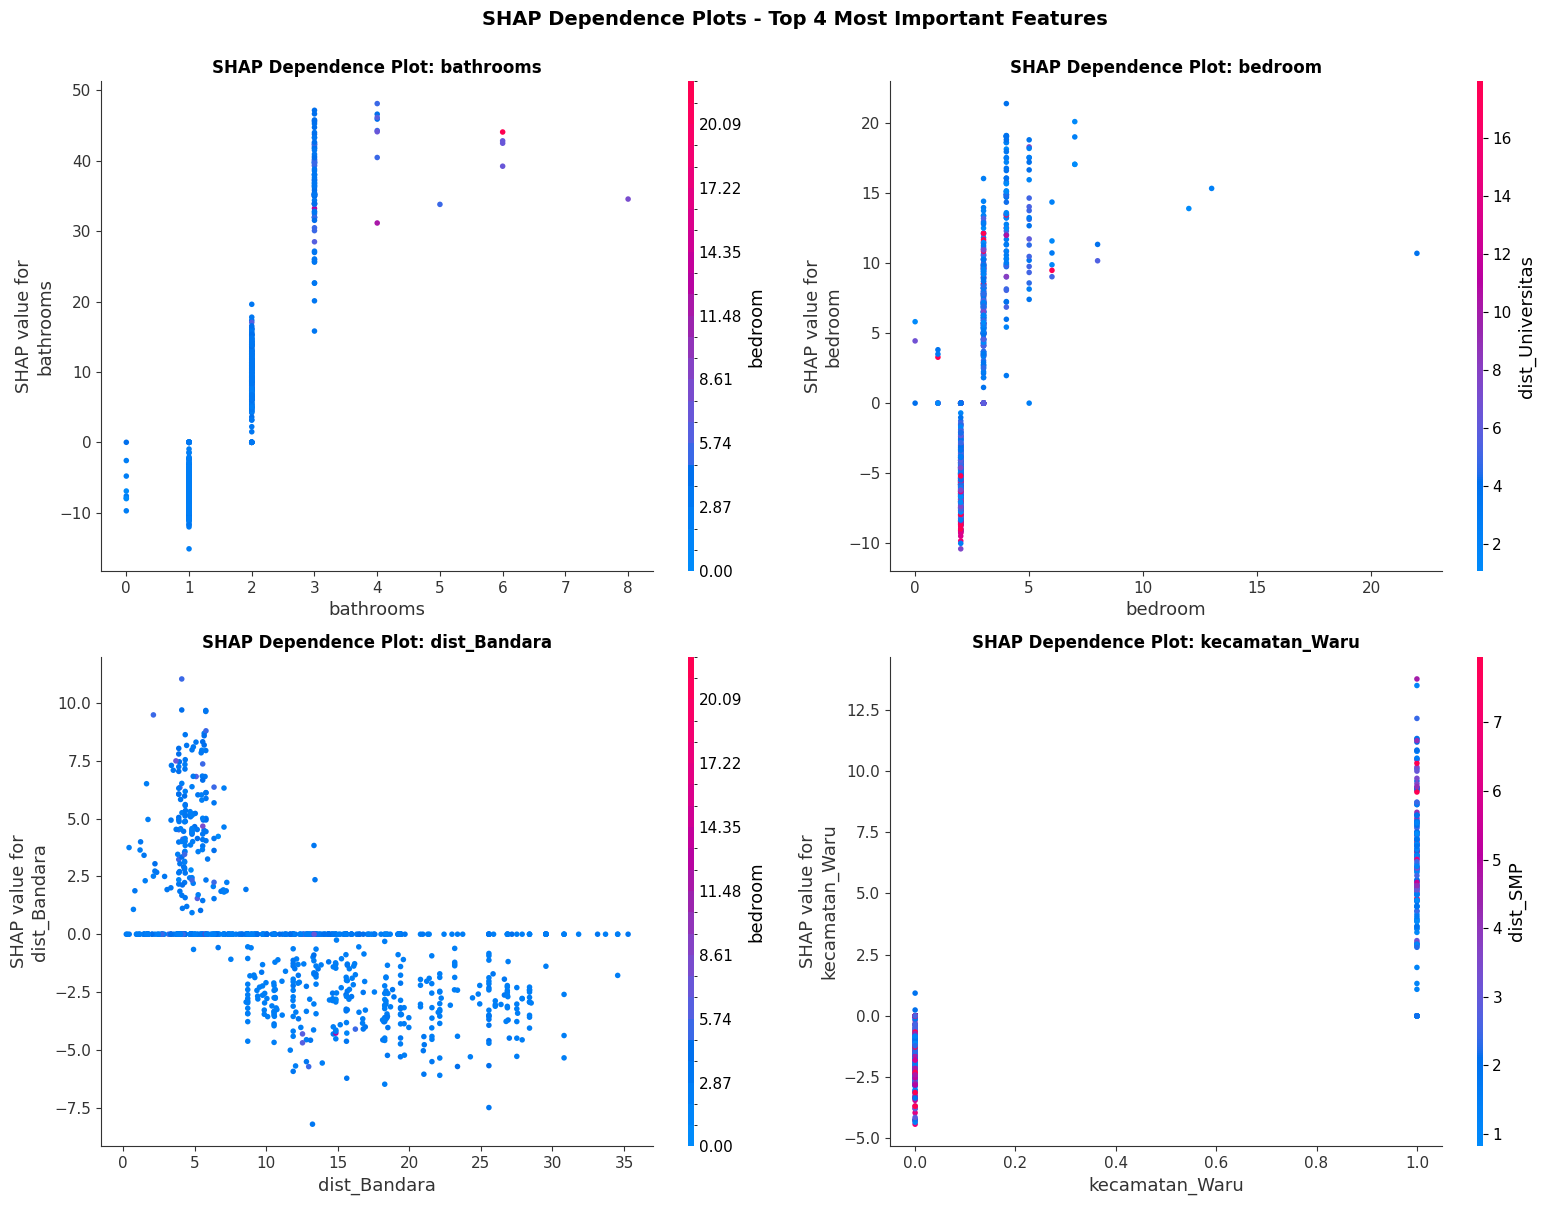

In [24]:
# SHAP Dependence Plot - Top 4 features
if shap_values_original is not None:
    # Get top 4 features by mean absolute SHAP
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.abs(shap_values_original).mean(axis=0)
    }).sort_values('importance', ascending=False)

    top_4_features = shap_importance.head(4)['feature'].tolist()
    top_4_indices = [feature_names.index(f) for f in top_4_features]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, (feature, feat_idx) in enumerate(zip(top_4_features, top_4_indices)):
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx,
            shap_values_original,
            X_shap_np,
            feature_names=feature_names,
            interaction_index="auto",
            show=False,
            ax=axes[i]
        )
        axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12, fontweight='bold')

    plt.suptitle('SHAP Dependence Plots - Top 4 Most Important Features', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping dependence plots.")


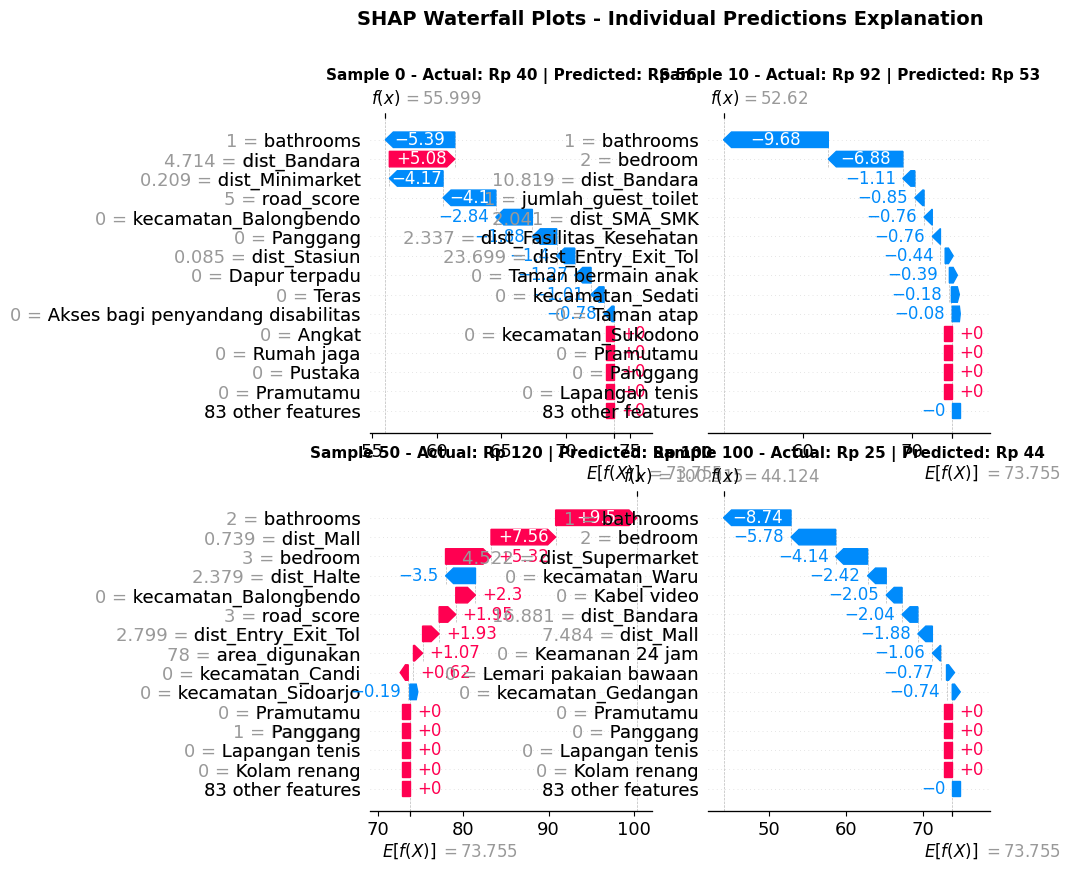

In [25]:
# SHAP Waterfall Plot - Contoh prediksi individual
if shap_values_original is not None and expected_value_original is not None:
    sample_idx = [0, 10, 50, 100]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, idx in enumerate(sample_idx):
        if idx < len(X_shap_np):
            plt.sca(axes[i])
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_original[idx],
                    base_values=float(expected_value_original),
                    data=X_shap_np[idx],
                    feature_names=feature_names
                ),
                max_display=15,
                show=False
            )
            
            actual_price = X_shap_target_original[idx]
            predicted_price = train_pred_original[idx]
            axes[i].set_title(f'Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}', 
                             fontsize=11, fontweight='bold')

    plt.suptitle('SHAP Waterfall Plots - Individual Predictions Explanation', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")


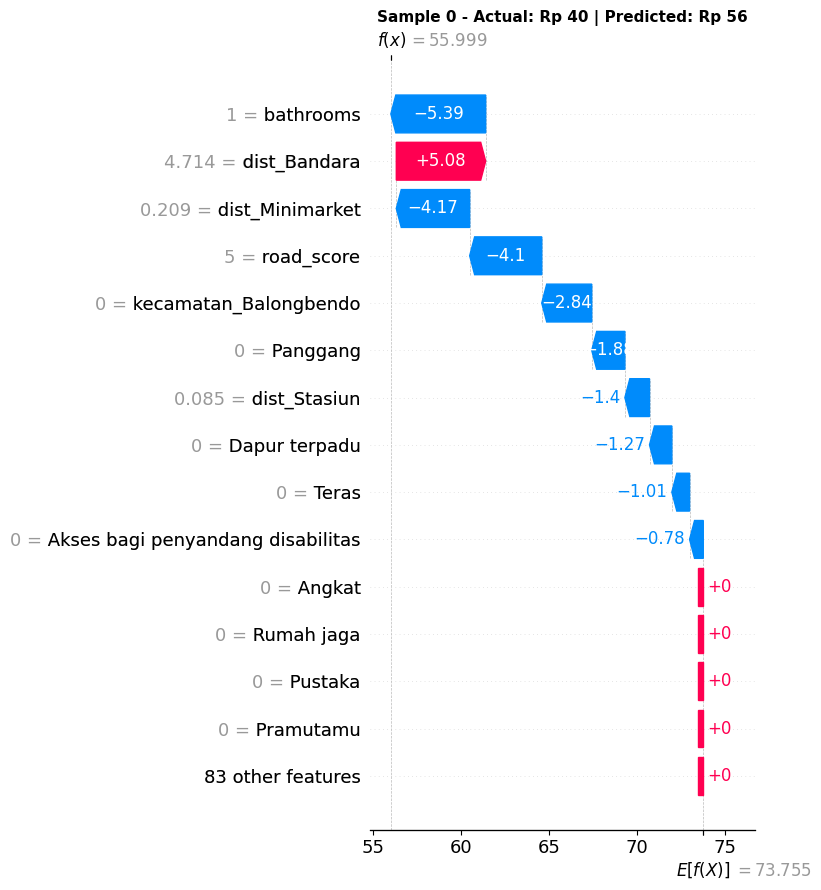

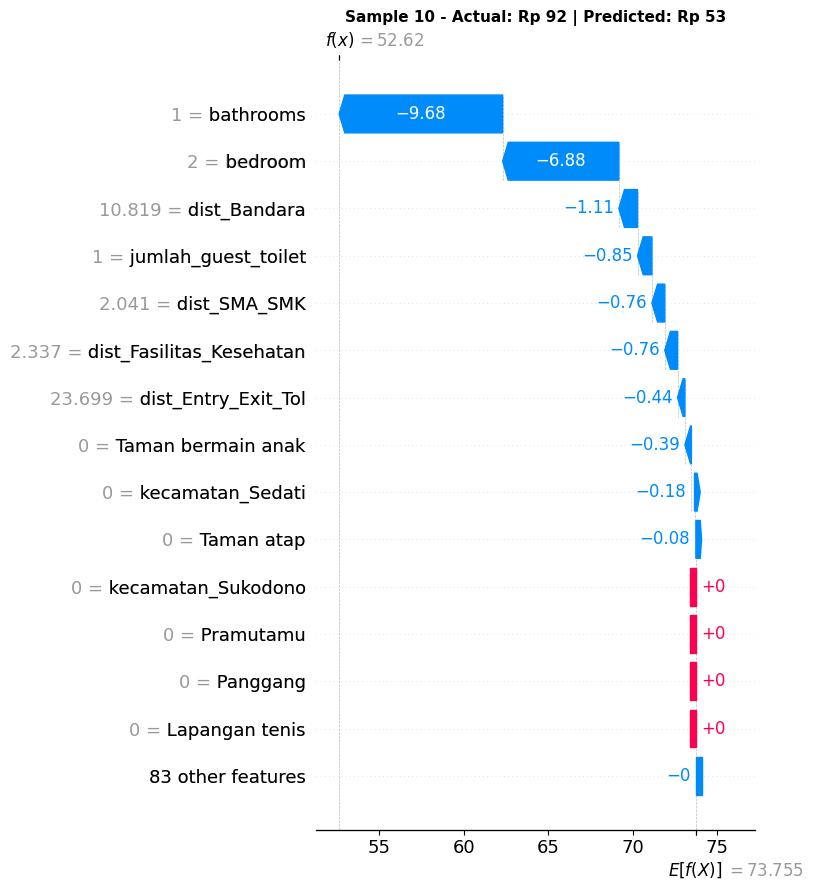

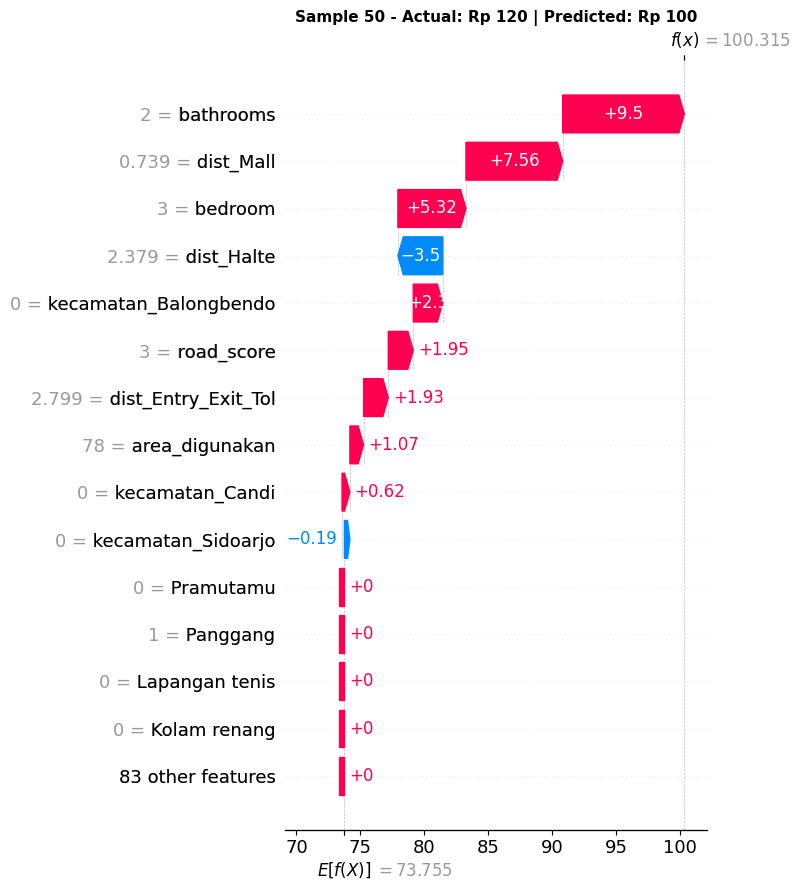

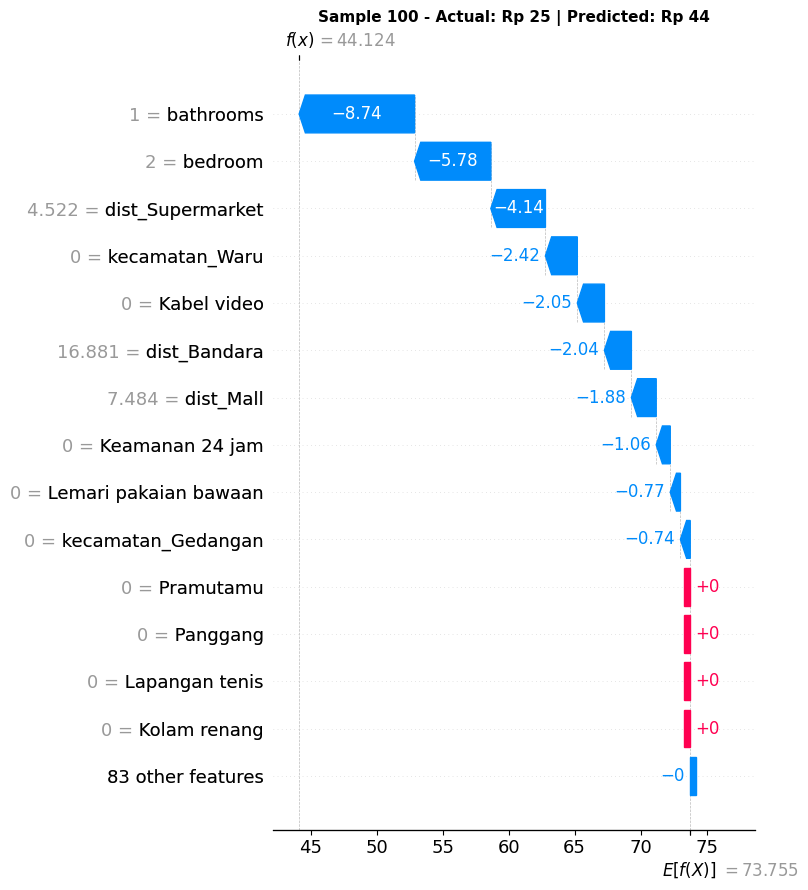

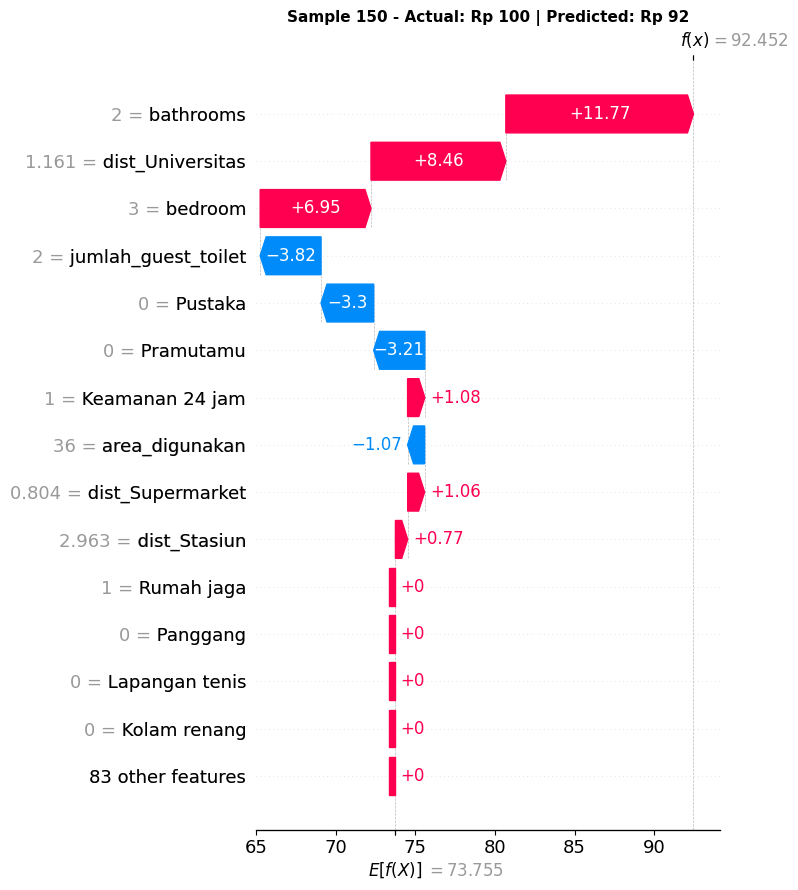

In [26]:
# SHAP Waterfall Plot - Output satu per satu (5 sampel)
if shap_values_original is not None and expected_value_original is not None:
    
    sample_idx = [0, 10, 50, 100, 150]  # 5 contoh
    
    for idx in sample_idx:
        if idx < len(X_shap_np):
            
            plt.figure(figsize=(10, 6))  # Buat figure baru tiap loop
            
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_original[idx],
                    base_values=float(expected_value_original),
                    data=X_shap_np[idx],
                    feature_names=feature_names
                ),
                max_display=15,
                show=False
            )
            
            actual_price = X_shap_target_original[idx]
            predicted_price = train_pred_original[idx]
            
            plt.title(
                f'Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}',
                fontsize=11,
                fontweight='bold'
            )
            
            plt.tight_layout()
            plt.show()  # tampilkan satu-satu

else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")

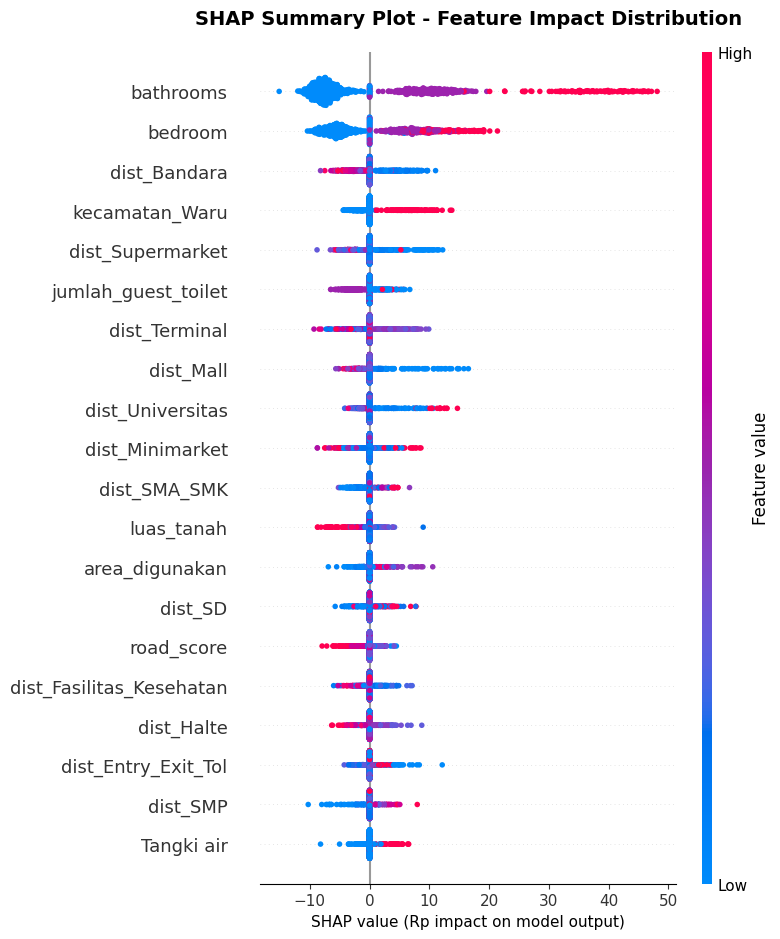

In [27]:
# SHAP Summary Plot - Beeswarm (Feature Impact Distribution)
if shap_values_original is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_original, X_shap_np, feature_names=feature_names, max_display=20, show=False)
    plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('SHAP value (Rp impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping beeswarm plot.")


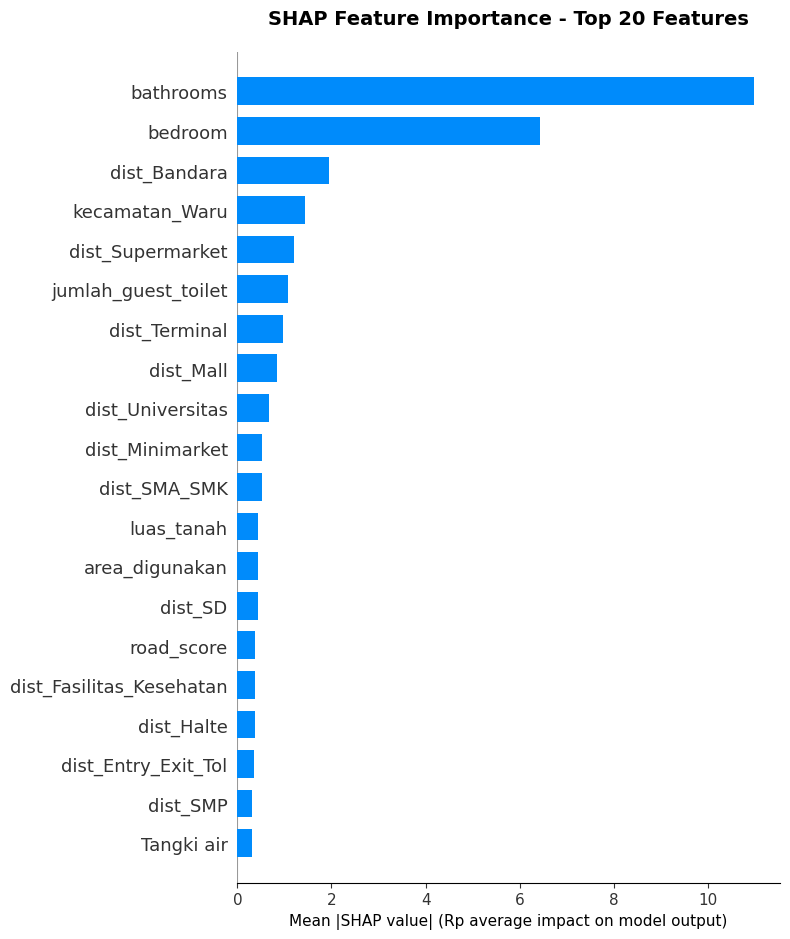

In [28]:
# SHAP Summary Plot - Bar (Feature Importance)
if shap_values_original is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_original, X_shap_np, feature_names=feature_names, plot_type="bar", max_display=20, show=False)
    plt.title('SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Mean |SHAP value| (Rp average impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping bar plot.")


## CatBoost

In [29]:
from catboost import CatBoostRegressor

In [30]:
# TARGET & FEATURE untuk CatBoost
y_train_CB = train_df_transformed["Harga_Asli"]
X_train_CB = train_df_transformed.drop(columns=["Harga_Asli", "latitude", "longitude"])

y_test_CB = val_df_transformed["Harga_Asli"]
X_test_CB = val_df_transformed.drop(columns=["Harga_Asli", "latitude", "longitude"])

In [31]:
catboost_model = CatBoostRegressor(
    loss_function='RMSE',
    task_type='CPU',         
    devices='0',              
    gpu_ram_part=0.5,          
    verbose=0,
    random_state=42,
    # GPU-specific optimizations
    max_ctr_complexity=4
)

param_dist_cb = {
    "iterations": randint(300, 800),
    "depth": randint(4, 10),
    "learning_rate": uniform(0.01, 0.2),
    "l2_leaf_reg": uniform(1, 10),
    "border_count": [32, 64, 128, 254],
    "bagging_temperature": uniform(0, 1),
    "random_strength": uniform(0, 2),
    "bootstrap_type": ['MVS']
}

### Cross Validation

In [32]:
import warnings
warnings.filterwarnings('ignore')

cv = KFold(n_splits=5)

random_search_cb = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_dist_cb,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=1,
    error_score="raise"
)

random_search_cb.fit(
    X_train_CB,
    y_train_CB
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   0.9s
[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   0.8s
[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   0.8s
[CV] END bagging_temperature=0.3745401188473625, bootstrap_type=MVS, border_count=32, depth=6, iterations=371, l2_leaf_reg=6.986584841970366, learning_rate=0.0412037280884873, random_strength=0.3119890406724053; total time=   0.7s
[CV] END baggi

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   error_score='raise',
                   estimator=<catboost.core.CatBoostRegressor object at 0x0000014226602C50>,
                   n_iter=50, n_jobs=1,
                   param_distributions={'bagging_temperature': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001422661C150>,
                                        'bootstrap_type': ['MVS'],
                                        'border_count': [32...
                                        'l2_leaf_reg': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000014226603B10>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000014226603710>,
                                        'random_strength': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001422661C790>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [33]:
best_model = random_search_cb.best_estimator_
best_model_cb = best_model

print("Best Params:")
print(random_search_cb.best_params_)

Best Params:
{'bagging_temperature': 0.9422017556848528, 'bootstrap_type': 'MVS', 'border_count': 64, 'depth': 5, 'iterations': 564, 'l2_leaf_reg': 1.159662522202142, 'learning_rate': 0.056178765124429805, 'random_strength': 0.48205093205202343}


In [57]:
# Evaluasi train vs test - CatBoost
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Prediksi pada skala transformasi
y_pred_train_cb = best_model_cb.predict(X_train_CB)
y_pred_test_cb = best_model_cb.predict(X_test_CB)

# Kembalikan ke skala harga asli
zscaler = fitted_transformers['harga_asli']
y_train_cb_orig = zscaler.inverse_transform(y_train_CB.values.reshape(-1, 1)).ravel()
y_test_cb_orig = zscaler.inverse_transform(y_test_CB.values.reshape(-1, 1)).ravel()
y_pred_train_cb_orig = zscaler.inverse_transform(y_pred_train_cb.reshape(-1, 1)).ravel()
y_pred_test_cb_orig = zscaler.inverse_transform(y_pred_test_cb.reshape(-1, 1)).ravel()

def regression_report(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

cb_train_metrics = regression_report(y_train_cb_orig, y_pred_train_cb_orig)
cb_test_metrics = regression_report(y_test_cb_orig, y_pred_test_cb_orig)

cb_eval = pd.DataFrame([cb_train_metrics, cb_test_metrics], index=["Train", "Test"])
print("CatBoost Evaluation (Tanpa Rp)")
display(
    cb_eval.style.format({
        "R2": "{:.4f}",
        "MSE": "{:.2f}",
        "RMSE": "{:.2f}",
        "MAE": "{:.2f}"
    })
)

# Perbandingan prediksi vs aktual (test set) tetap Rupiah
comparison_df_cb = pd.DataFrame({
    "Harga Aktual": y_test_cb_orig.flatten(),
    "Harga Prediksi": y_pred_test_cb_orig.flatten(),
    "Selisih (Absolut)": np.abs(y_test_cb_orig.flatten() - y_pred_test_cb_orig.flatten())
})
print("Perbandingan Prediksi vs Aktual - CatBoost (Test, Skala Asli)")
display(
    comparison_df_cb.head(10).style.format({
        "Harga Aktual": "Rp {:,.2f}",
        "Harga Prediksi": "Rp {:,.2f}",
        "Selisih (Absolut)": "Rp {:,.2f}"
    })
)

CatBoost Evaluation (Tanpa Rp)


,R2,MSE,RMSE,MAE
Train,0.8807,215.20,14.67,9.28
Test,0.6875,697.38,26.41,18.55


Perbandingan Prediksi vs Aktual - CatBoost (Test, Skala Asli)


,Harga Aktual,Harga Prediksi,Selisih (Absolut)
0,Rp 49.48,Rp 49.18,Rp 0.30
1,Rp 48.00,Rp 38.07,Rp 9.93
2,Rp 39.00,Rp 59.69,Rp 20.69
3,Rp 50.00,Rp 45.42,Rp 4.58
4,Rp 141.00,Rp 96.42,Rp 44.58
5,Rp 150.00,Rp 39.83,Rp 110.17
6,Rp 15.00,Rp 37.37,Rp 22.37
7,Rp 190.00,Rp 107.14,Rp 82.86
8,Rp 40.00,Rp 44.67,Rp 4.67
9,Rp 58.50,Rp 42.42,Rp 16.08


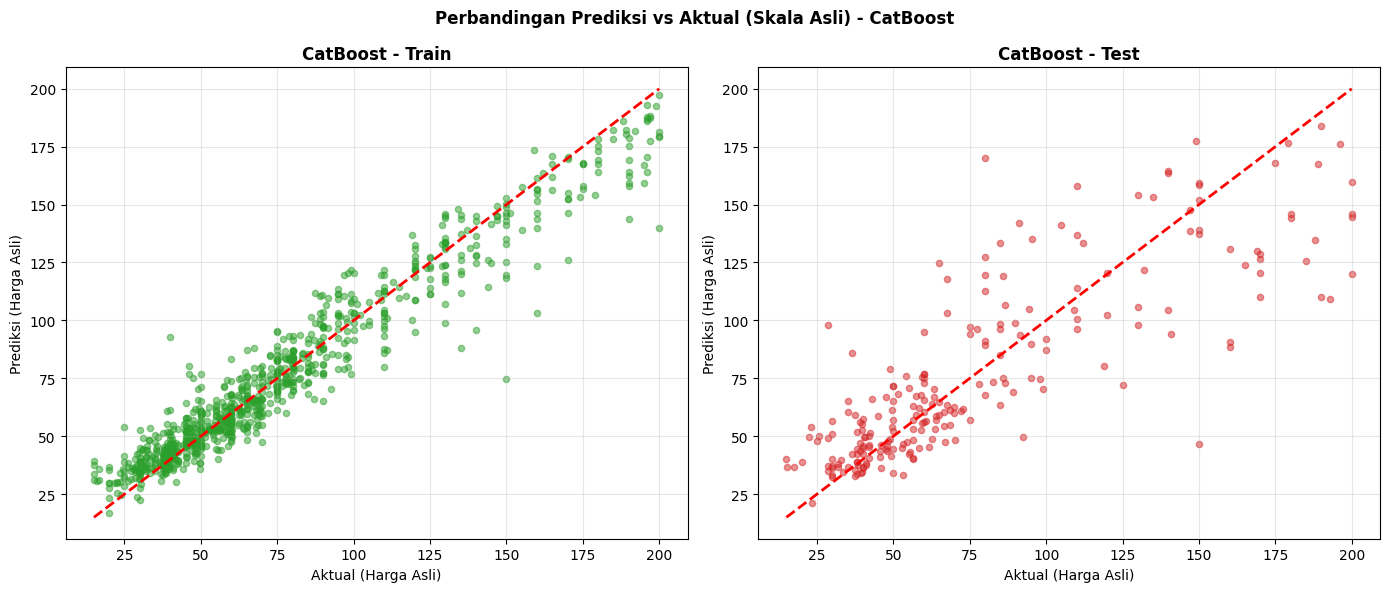

In [35]:
# Perbandingan Prediksi vs Aktual (Skala Asli) - CatBoost
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train plot
axes[0].scatter(y_train_cb_orig, y_pred_train_cb_orig, alpha=0.5, s=20, color='#2ca02c')
min_train = min(y_train_cb_orig.min(), y_pred_train_cb_orig.min())
max_train = max(y_train_cb_orig.max(), y_pred_train_cb_orig.max())
axes[0].plot([min_train, max_train], [min_train, max_train], 'r--', linewidth=2)
axes[0].set_title('CatBoost - Train', fontweight='bold')
axes[0].set_xlabel('Aktual (Harga Asli)')
axes[0].set_ylabel('Prediksi (Harga Asli)')
axes[0].grid(alpha=0.3)

# Test plot
axes[1].scatter(y_test_cb_orig, y_pred_test_cb_orig, alpha=0.5, s=20, color='#d62728')
min_test = min(y_test_cb_orig.min(), y_pred_test_cb_orig.min())
max_test = max(y_test_cb_orig.max(), y_pred_test_cb_orig.max())
axes[1].plot([min_test, max_test], [min_test, max_test], 'r--', linewidth=2)
axes[1].set_title('CatBoost - Test', fontweight='bold')
axes[1].set_xlabel('Aktual (Harga Asli)')
axes[1].set_ylabel('Prediksi (Harga Asli)')
axes[1].grid(alpha=0.3)

plt.suptitle('Perbandingan Prediksi vs Aktual (Skala Asli) - CatBoost', fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
results = []

for train_idx, test_idx in cv.split(X_train_CB, y_train_CB):
    X_train_fold, X_test = X_train_CB.iloc[train_idx], X_train_CB.iloc[test_idx]
    y_train_fold, y_test = y_train_CB.iloc[train_idx], y_train_CB.iloc[test_idx]

    model = best_model
    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "n_samples": len(y_test),
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

eval_df = pd.DataFrame(results)
print("CV Results (Global):")
print(eval_df)


CV Results (Global):
   n_samples        R2       MSE      RMSE       MAE
0        184  0.555240  0.438260  0.662012  0.446043
1        183  0.626339  0.385888  0.621199  0.414623
2        183  0.566488  0.442132  0.664930  0.462570
3        183  0.630996  0.389753  0.624302  0.445282
4        183  0.554078  0.400759  0.633055  0.437044


In [37]:
cv_summary = pd.DataFrame({
    "R2_mean": [eval_df["R2"].mean()],
    "R2_std": [eval_df["R2"].std()],
    "MSE_mean": [eval_df["MSE"].mean()],
    "MSE_std": [eval_df["MSE"].std()],
    "RMSE_mean": [eval_df["RMSE"].mean()],
    "RMSE_std": [eval_df["RMSE"].std()],
    "MAE_mean": [eval_df["MAE"].mean()],
    "MAE_std": [eval_df["MAE"].std()]
})

print("="*60)
print("CROSS-VALIDATION SUMMARY (GLOBAL)")
print("="*60)
print(cv_summary.to_string(index=False))


CROSS-VALIDATION SUMMARY (GLOBAL)
 R2_mean   R2_std  MSE_mean  MSE_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
0.586628 0.038716  0.411358 0.026919     0.6411  0.020905  0.441112 0.017467


In [38]:
importance = pd.DataFrame({
    "feature": X_train_CB.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

                     feature  importance
1                  bathrooms   21.601196
0                    bedroom   10.416452
15             dist_Terminal    5.446050
18       dist_Entry_Exit_Tol    4.425534
5                 luas_tanah    3.792208
16              dist_Bandara    3.695992
12          dist_Supermarket    3.488475
9           dist_Universitas    3.460963
4             area_digunakan    3.353663
7                   dist_SMP    3.299422
11                 dist_Mall    3.218798
13           dist_Minimarket    2.654288
2        jumlah_guest_toilet    2.643104
14              dist_Stasiun    2.365584
8               dist_SMA_SMK    2.092906
10  dist_Fasilitas_Kesehatan    2.086519
6                    dist_SD    1.866992
17                dist_Halte    1.826607
95            kecamatan_Waru    1.569726
54                Tangki air    1.562517


In [39]:
#importance.to_csv('C:/skripsi/rev6_apr/rev_code/fitur2/4_feature_importance_Catboost.csv', index=False)

CATBOOST FEATURE IMPORTANCE ANALYSIS


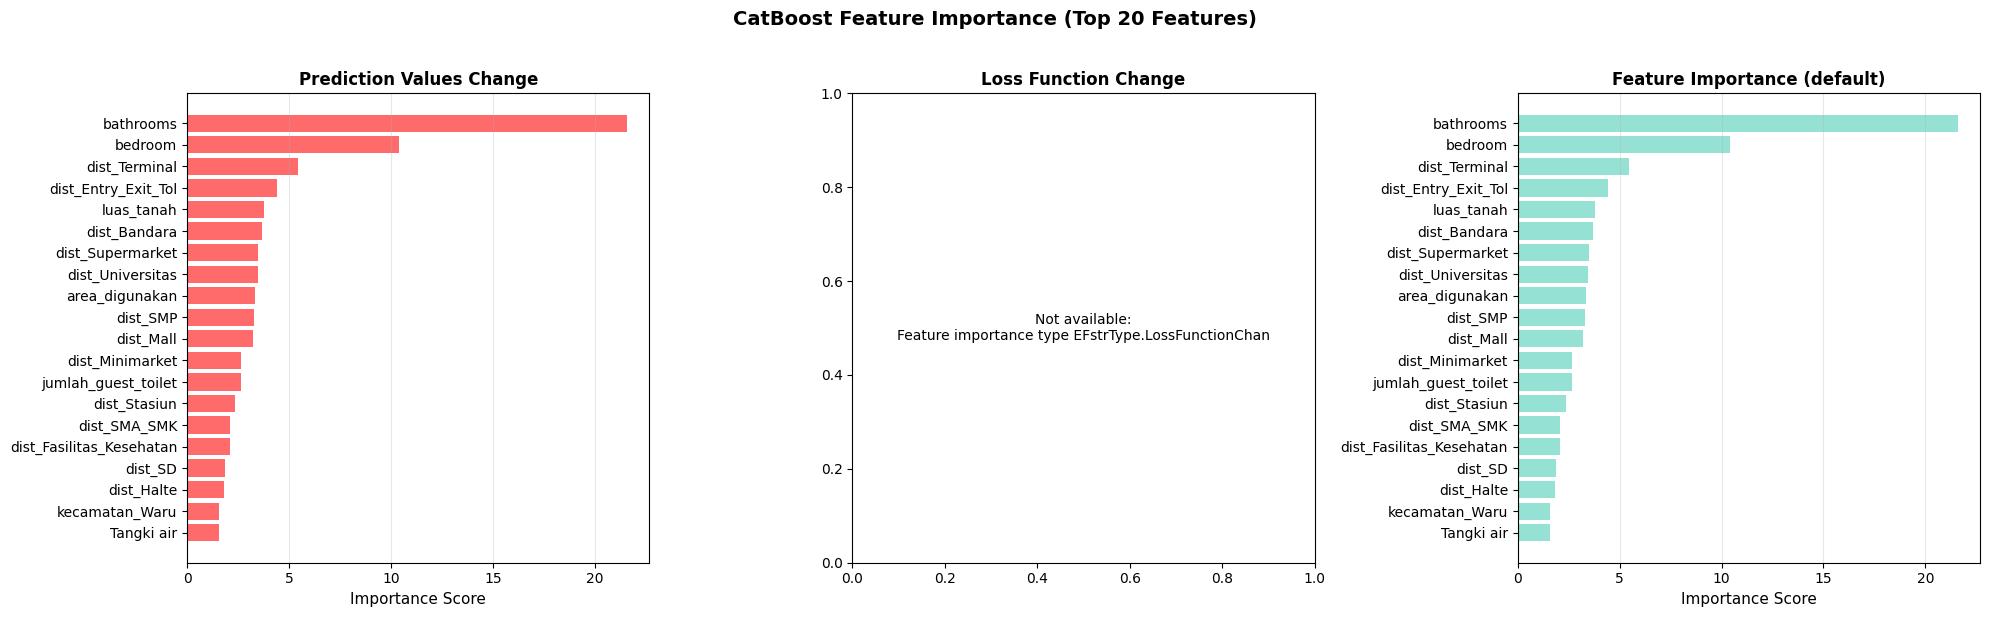


DETAILED FEATURE IMPORTANCE COMPARISON

Top 20 Most Important Features:
                 feature  importance_default  importance_pvc
               bathrooms           21.601196       21.601196
                 bedroom           10.416452       10.416452
           dist_Terminal            5.446050        5.446050
     dist_Entry_Exit_Tol            4.425534        4.425534
              luas_tanah            3.792208        3.792208
            dist_Bandara            3.695992        3.695992
        dist_Supermarket            3.488475        3.488475
        dist_Universitas            3.460963        3.460963
          area_digunakan            3.353663        3.353663
                dist_SMP            3.299422        3.299422
               dist_Mall            3.218798        3.218798
         dist_Minimarket            2.654288        2.654288
     jumlah_guest_toilet            2.643104        2.643104
            dist_Stasiun            2.365584        2.365584
            

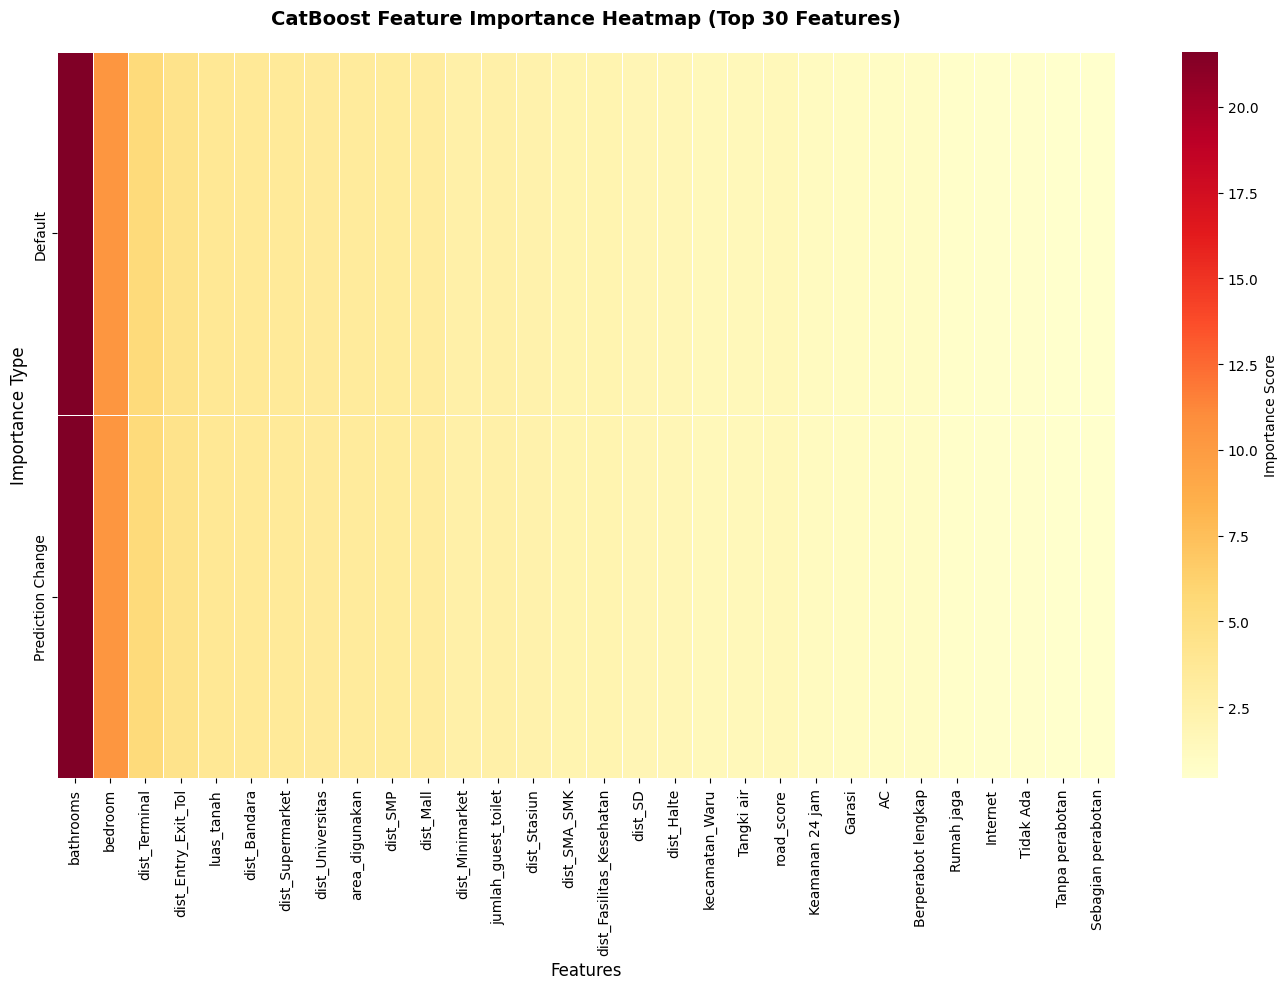

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CATBOOST FEATURE IMPORTANCE
# ============================================================================

# Method 1: Menggunakan get_feature_importance() - Native CatBoost
print("="*80)
print("CATBOOST FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Dapatkan feature importance dengan berbagai tipe
importance_types = {
    'PredictionValuesChange': 'Prediction Values Change',
    'LossFunctionChange': 'Loss Function Change', 
    'FeatureImportance': 'Feature Importance (default)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (imp_type, title) in enumerate(importance_types.items()):
    try:
        # Get importance scores
        importance_scores = best_model.get_feature_importance(
            type=imp_type,
            prettified=False
        )
        
        # Create DataFrame
        importance_df = pd.DataFrame({
            'feature': X_train_CB.columns,
            'importance': importance_scores
        }).sort_values('importance', ascending=True).tail(20)
        
        # Plot
        axes[idx].barh(range(len(importance_df)), importance_df['importance'], color=['#FF6B6B', '#4ECDC4', '#95E1D3'][idx])
        axes[idx].set_yticks(range(len(importance_df)))
        axes[idx].set_yticklabels(importance_df['feature'])
        axes[idx].set_xlabel('Importance Score', fontsize=11)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Not available:\n{str(e)[:50]}', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('CatBoost Feature Importance (Top 20 Features)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Method 2: Detailed DataFrame Analysis
print("\n" + "="*80)
print("DETAILED FEATURE IMPORTANCE COMPARISON")
print("="*80)

importance_comparison = pd.DataFrame({
    'feature': X_train_CB.columns,
    'importance_default': best_model.get_feature_importance(prettified=False)
})

# Tambahkan tipe lain jika tersedia
try:
    importance_comparison['importance_pvc'] = best_model.get_feature_importance(
        type='PredictionValuesChange', prettified=False
    )
except:
    pass

try:
    importance_comparison['importance_lfc'] = best_model.get_feature_importance(
        type='LossFunctionChange', prettified=False
    )
except:
    pass

# Sort by default importance
importance_comparison = importance_comparison.sort_values('importance_default', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance_comparison.head(20).to_string(index=False))

# Method 3: Heatmap untuk perbandingan
plt.figure(figsize=(14, 10))

# Ambil top 30 features
top_30 = importance_comparison.head(30).copy()

# Pilih kolom numerik saja
numeric_cols = [col for col in top_30.columns if col.startswith('importance_')]
heatmap_data = top_30[numeric_cols].T

# Rename untuk label lebih baik
rename_map = {
    'importance_default': 'Default',
    'importance_pvc': 'Prediction Change',
    'importance_lfc': 'Loss Change'
}
heatmap_data.index = [rename_map.get(idx, idx) for idx in heatmap_data.index]

sns.heatmap(
    heatmap_data,
    xticklabels=top_30['feature'].values,
    yticklabels=heatmap_data.index,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Importance Score'},
    linewidths=0.5
)

plt.title('CatBoost Feature Importance Heatmap (Top 30 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance Type', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### SHAP

In [41]:
# SHAP Analysis untuk CatBoost
# CatBoost memiliki native support yang lebih baik untuk SHAP!

import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SHAP ANALYSIS - CATBOOST MODEL")
print("="*80)

# Ambil skala asli target agar seluruh output SHAP kembali ke rupiah asli
target_transformer = fitted_transformers['harga_asli']
target_mean = float(target_transformer.mean_)
target_std = float(target_transformer.std_)

# Step 1: Ambil sample data untuk efisiensi komputasi
print("\n[1/4] Preparing data for SHAP analysis...")

n_samples = min(1000, len(X_train_CB))
sample_indices = X_train_CB.sample(n_samples, random_state=42).index
X_shap_sample = X_train_CB.loc[sample_indices].copy()
y_shap_sample = y_train_CB.loc[sample_indices].copy()

# Simpan nama kolom
feature_names_cb = X_shap_sample.columns.tolist()

print(f"   Sample size: {X_shap_sample.shape}")
print(f"   Features: {len(feature_names_cb)}")

# Step 2: Create SHAP explainer - SANGAT MUDAH dengan CatBoost!
print("\n[2/4] Creating SHAP TreeExplainer for CatBoost...")
shap_success = False
shap_values_cb = None
explainer_cb = None
expected_value_cb = None

try:
    # CatBoost native support - langsung gunakan model yang sudah di-train!
    explainer_cb = shap.TreeExplainer(best_model)
    expected_value_cb = explainer_cb.expected_value
    print("   ✓ TreeExplainer created successfully")
    print(f"   ✓ Base value: Rp {float(expected_value_cb):,.0f}")
    shap_success = True
except Exception as e:
    print(f"   ✗ TreeExplainer failed: {str(e)}")
    shap_success = False

# Step 3: Calculate SHAP values
if shap_success and explainer_cb is not None:
    print("\n[3/4] Calculating SHAP values...")
    try:
        shap_values_cb = explainer_cb.shap_values(X_shap_sample)
        shap_values_cb_original = shap_values_cb * target_std
        expected_value_cb_original = float(expected_value_cb) * target_std + target_mean
        y_shap_sample_original = y_shap_sample.values * target_std + target_mean
        
        print(f"   ✓ SHAP values calculated!")
        print(f"   Shape: {shap_values_cb_original.shape}")
        
        # Step 4: Verify with predictions
        print("\n[4/4] Verifying model performance on sample...")
        train_pred_cb = best_model.predict(X_shap_sample)
        train_pred_cb_original = train_pred_cb * target_std + target_mean
        train_rmse = np.sqrt(mean_squared_error(y_shap_sample_original, train_pred_cb_original))
        train_mae = mean_absolute_error(y_shap_sample_original, train_pred_cb_original)
        print(f"   RMSE: Rp {train_rmse:,.0f}")
        print(f"   MAE: Rp {train_mae:,.0f}")
        
        print("\n" + "="*80)
        print("✓ CATBOOST SHAP ANALYSIS COMPLETED SUCCESSFULLY!")
        print("="*80)
        
    except Exception as e:
        print(f"\n   ✗ Failed to calculate SHAP values: {e}")
        shap_success = False
        shap_values_cb = None
        shap_values_cb_original = None
        expected_value_cb_original = None
else:
    print("\n" + "="*80)
    print("✗ SHAP ANALYSIS FAILED")
    print("="*80)
    shap_values_cb = None
    shap_values_cb_original = None
    expected_value_cb_original = None
    train_pred_cb = None
    train_pred_cb_original = None
    y_shap_sample_original = None


SHAP ANALYSIS - CATBOOST MODEL

[1/4] Preparing data for SHAP analysis...
   Sample size: (916, 97)
   Features: 97

[2/4] Creating SHAP TreeExplainer for CatBoost...
   ✓ TreeExplainer created successfully
   ✓ Base value: Rp -0

[3/4] Calculating SHAP values...
   ✓ SHAP values calculated!
   Shape: (916, 97)

[4/4] Verifying model performance on sample...
   RMSE: Rp 15
   MAE: Rp 9

✓ CATBOOST SHAP ANALYSIS COMPLETED SUCCESSFULLY!


In [42]:
# Summary Statistics SHAP Values - CatBoost
if shap_values_cb_original is not None:
    print("="*80)
    print("CATBOOST SHAP ANALYSIS SUMMARY")
    print("="*80)

    shap_summary_cb = pd.DataFrame({
        'Feature': feature_names_cb,
        'Mean_|SHAP|': np.abs(shap_values_cb_original).mean(axis=0),
        'Std_SHAP': np.abs(shap_values_cb_original).std(axis=0),
        'Max_|SHAP|': np.abs(shap_values_cb_original).max(axis=0),
        'Mean_SHAP': shap_values_cb_original.mean(axis=0)
    }).sort_values('Mean_|SHAP|', ascending=False)

    print("\nTop 20 Features by Mean Absolute SHAP Value:")
    print(shap_summary_cb.head(20).to_string(index=False))

    print("\n" + "="*80)
    print(f"Model Base Value (Expected): Rp {float(expected_value_cb_original):,.0f}")
    print(f"Mean Prediction: Rp {train_pred_cb_original.mean():,.0f}")
    print(f"Actual Mean Price: Rp {y_shap_sample_original.mean():,.0f}")
    print("="*80)
else:
    print("⚠ SHAP values not available. Skipping summary.")


CATBOOST SHAP ANALYSIS SUMMARY

Top 20 Features by Mean Absolute SHAP Value:
                 Feature  Mean_|SHAP|  Std_SHAP  Max_|SHAP|  Mean_SHAP
               bathrooms    14.621004  8.729727   57.857117  -0.388008
                 bedroom     8.032307  3.632402   59.686295   0.011416
     jumlah_guest_toilet     3.354587  0.992636    6.904404  -0.119163
            dist_Bandara     3.008817  1.652077    8.593853  -0.025903
        dist_Universitas     2.344444  1.323544    9.517510   0.188959
           dist_Terminal     2.300349  1.904266   10.771285   0.104629
               dist_Mall     2.215643  1.646120   12.792958   0.180092
        dist_Supermarket     1.868826  2.851336   28.121260  -0.079809
              luas_tanah     1.808329  2.126870   18.888984  -0.058893
            dist_SMA_SMK     1.745958  1.042152    6.223840   0.122922
         Keamanan 24 jam     1.667966  0.696691    6.513731   0.113241
     dist_Entry_Exit_Tol     1.616983  1.793636   14.865106  -0.051676


In [43]:
# Export SHAP values untuk analisis lebih lanjut - CatBoost
if shap_values_cb_original is not None:
    shap_df_cb = pd.DataFrame(
        shap_values_cb_original,
        columns=[f'shap_{col}' for col in feature_names_cb]
    )

    # Gabung dengan data asli
    shap_analysis_df_cb = pd.concat([
        X_shap_sample.reset_index(drop=True),
        shap_df_cb.reset_index(drop=True),
        pd.Series(y_shap_sample_original, name='actual_price')
    ], axis=1)

    # Tambahkan prediksi
    shap_analysis_df_cb['predicted_price'] = train_pred_cb_original
    shap_analysis_df_cb['prediction_error'] = shap_analysis_df_cb['actual_price'] - shap_analysis_df_cb['predicted_price']

    print("CatBoost SHAP Analysis DataFrame:")
    print(shap_analysis_df_cb.head())
    print(f"\nShape: {shap_analysis_df_cb.shape}")
else:
    print("⚠ SHAP values not available. Skipping export.")


CatBoost SHAP Analysis DataFrame:
   bedroom  bathrooms  jumlah_guest_toilet  lantai  area_digunakan  \
0        3          1                    0       1             100   
1        5          3                    0       1             125   
2        3          2                    0       1             140   
3        2          1                    1       1              45   
4        3          2                    1       1              84   

   luas_tanah   dist_SD  dist_SMP  dist_SMA_SMK  dist_Universitas  ...  \
0         118  0.158767  1.777258      1.211823          4.456698  ...   
1         120  1.588239  1.491888      1.870270          2.465939  ...   
2         120  1.329266  1.199338      1.227778          0.816918  ...   
3          78  1.126267  0.584706      0.871008          1.730460  ...   
4          84  3.655698  4.153967      4.333047          2.145324  ...   

   shap_kecamatan_Sukodono  shap_kecamatan_Taman  shap_kecamatan_Tanggulangin  \
0                 0

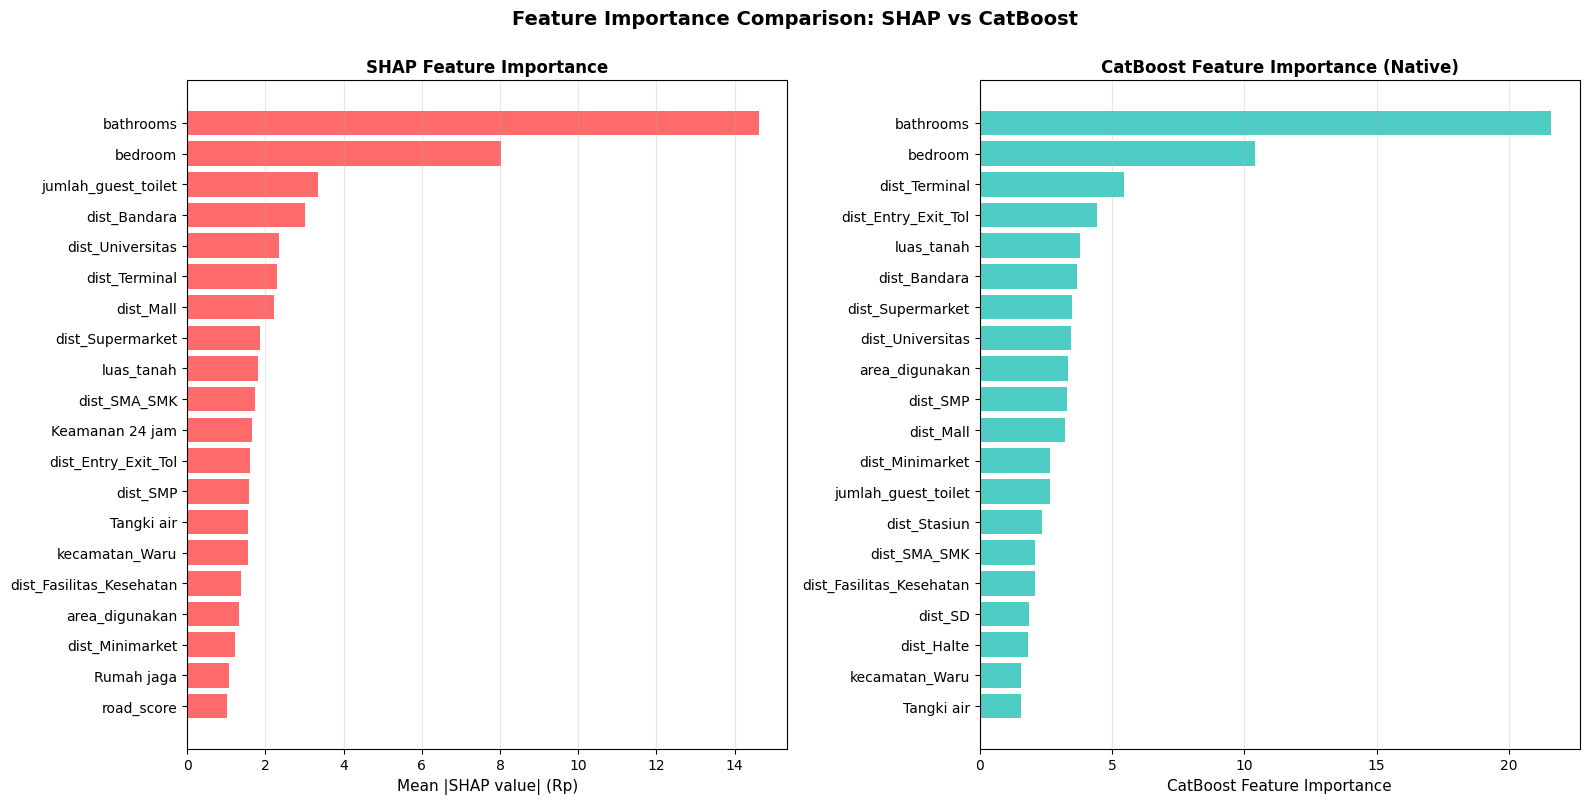

In [44]:
# SHAP Feature Importance Comparison dengan CatBoost Feature Importance
if shap_values_cb_original is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # SHAP Importance
    shap_importance_cb = pd.DataFrame({
        'feature': feature_names_cb,
        'shap_importance': np.abs(shap_values_cb_original).mean(axis=0)
    }).sort_values('shap_importance', ascending=True).tail(20)

    axes[0].barh(range(len(shap_importance_cb)), shap_importance_cb['shap_importance'], color='#FF6B6B')
    axes[0].set_yticks(range(len(shap_importance_cb)))
    axes[0].set_yticklabels(shap_importance_cb['feature'])
    axes[0].set_xlabel('Mean |SHAP value| (Rp)', fontsize=11)
    axes[0].set_title('SHAP Feature Importance', fontsize=12, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)

    # CatBoost Importance (Native)
    cb_importance = pd.DataFrame({
        'feature': X_train_CB.columns,
        'cb_importance': best_model.get_feature_importance()
    }).sort_values('cb_importance', ascending=True).tail(20)

    axes[1].barh(range(len(cb_importance)), cb_importance['cb_importance'], color='#4ECDC4')
    axes[1].set_yticks(range(len(cb_importance)))
    axes[1].set_yticklabels(cb_importance['feature'])
    axes[1].set_xlabel('CatBoost Feature Importance', fontsize=11)
    axes[1].set_title('CatBoost Feature Importance (Native)', fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Feature Importance Comparison: SHAP vs CatBoost', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping comparison plot.")


In [45]:
#shap_importance_cb.to_csv('C:/skripsi/rev6_apr/rev_code/fitur2/5_feature_importance_SHAP_Catboost_final.csv', index=False)


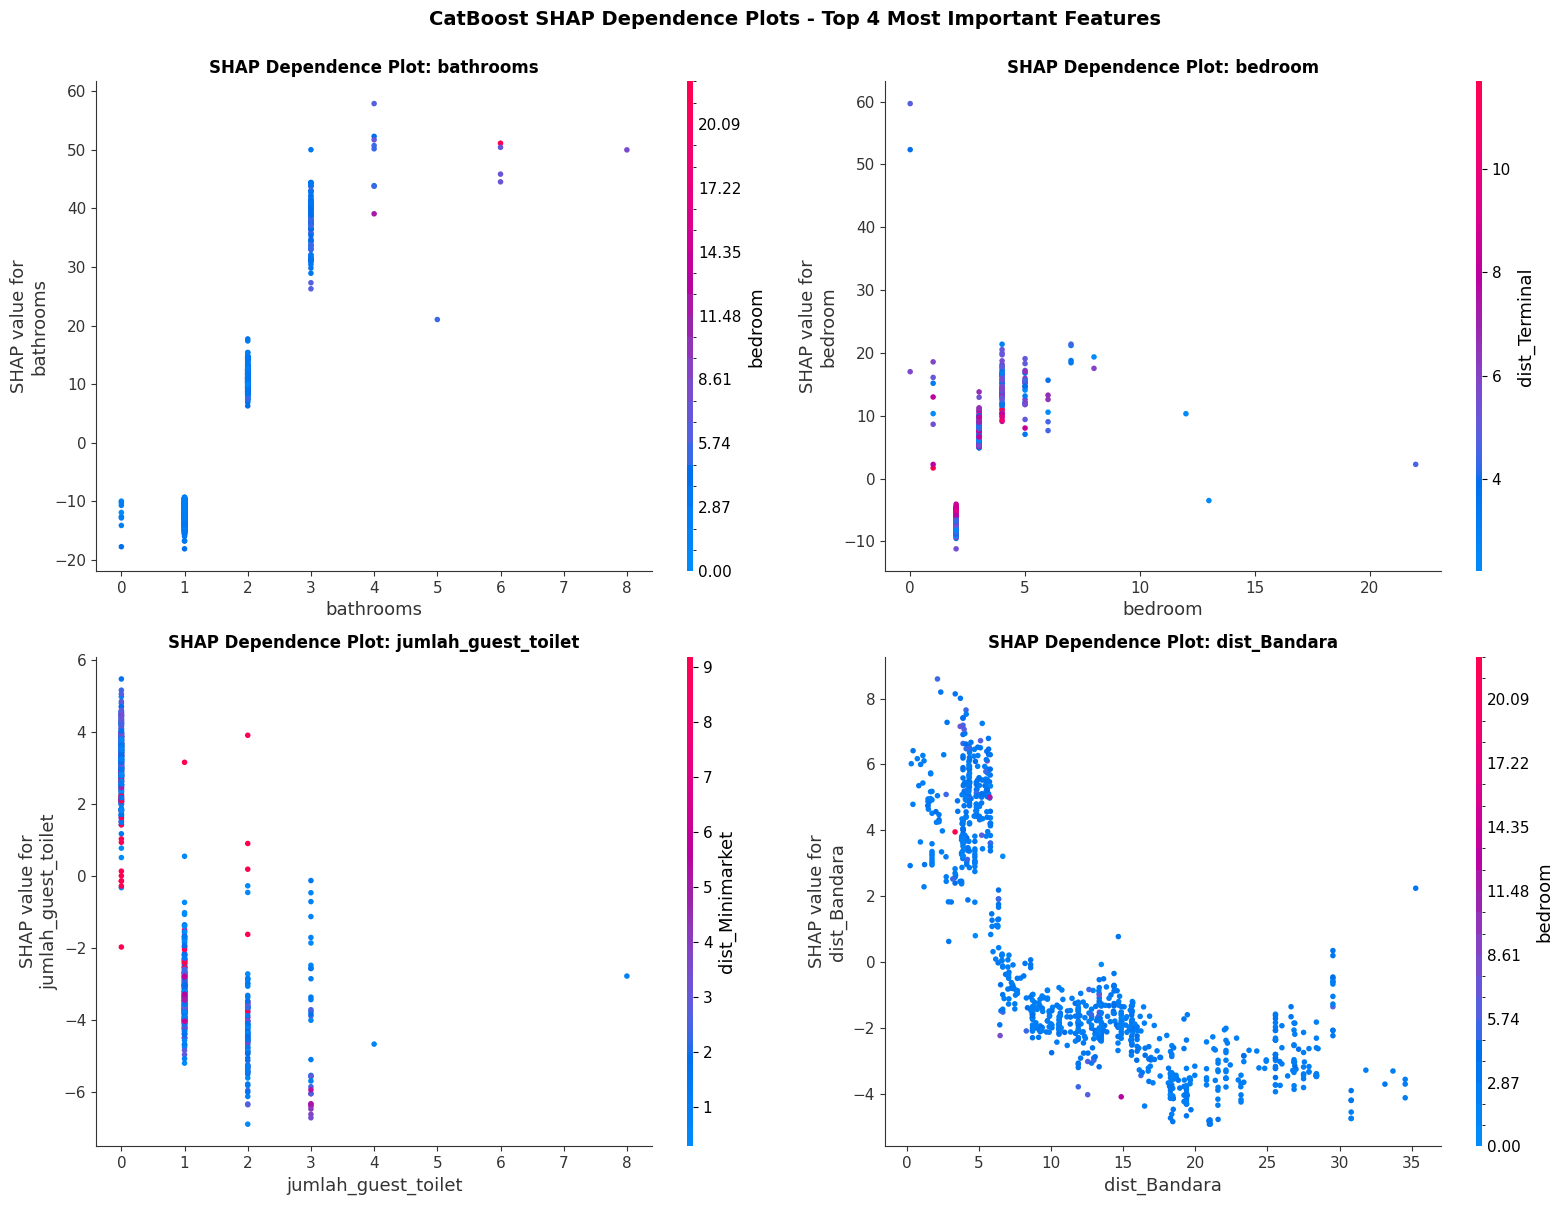

In [46]:
# SHAP Dependence Plot - Top 4 features - CatBoost
if shap_values_cb_original is not None:
    # Get top 4 features by mean absolute SHAP
    shap_importance_cb = pd.DataFrame({
        'feature': feature_names_cb,
        'importance': np.abs(shap_values_cb_original).mean(axis=0)
    }).sort_values('importance', ascending=False)

    top_4_features_cb = shap_importance_cb.head(4)['feature'].tolist()
    top_4_indices_cb = [feature_names_cb.index(f) for f in top_4_features_cb]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, (feature, feat_idx) in enumerate(zip(top_4_features_cb, top_4_indices_cb)):
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx,
            shap_values_cb_original,
            X_shap_sample,
            feature_names=feature_names_cb,
            interaction_index="auto",
            show=False,
            ax=axes[i]
        )
        axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12, fontweight='bold')

    plt.suptitle('CatBoost SHAP Dependence Plots - Top 4 Most Important Features', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping dependence plots.")


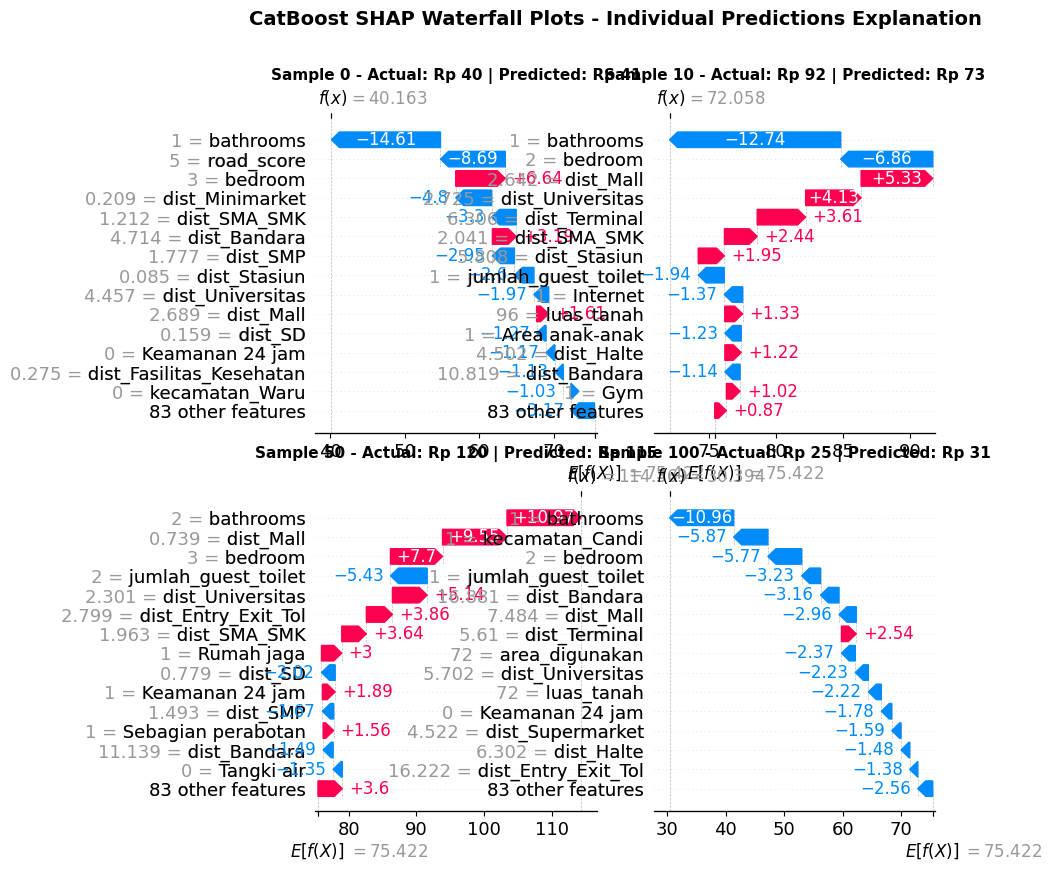

In [47]:
# SHAP Waterfall Plot - Contoh prediksi individual - CatBoost
if shap_values_cb_original is not None and expected_value_cb_original is not None:
    sample_idx = [0, 10, 50, 100]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()

    for i, idx in enumerate(sample_idx):
        if idx < len(X_shap_sample):
            plt.sca(axes[i])
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_cb_original[idx],
                    base_values=float(expected_value_cb_original),
                    data=X_shap_sample.iloc[idx].values,
                    feature_names=feature_names_cb
                ),
                max_display=15,
                show=False
            )
            
            actual_price = y_shap_sample_original[idx]
            predicted_price = train_pred_cb_original[idx]
            axes[i].set_title(f'Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}', 
                             fontsize=11, fontweight='bold')

    plt.suptitle('CatBoost SHAP Waterfall Plots - Individual Predictions Explanation', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")


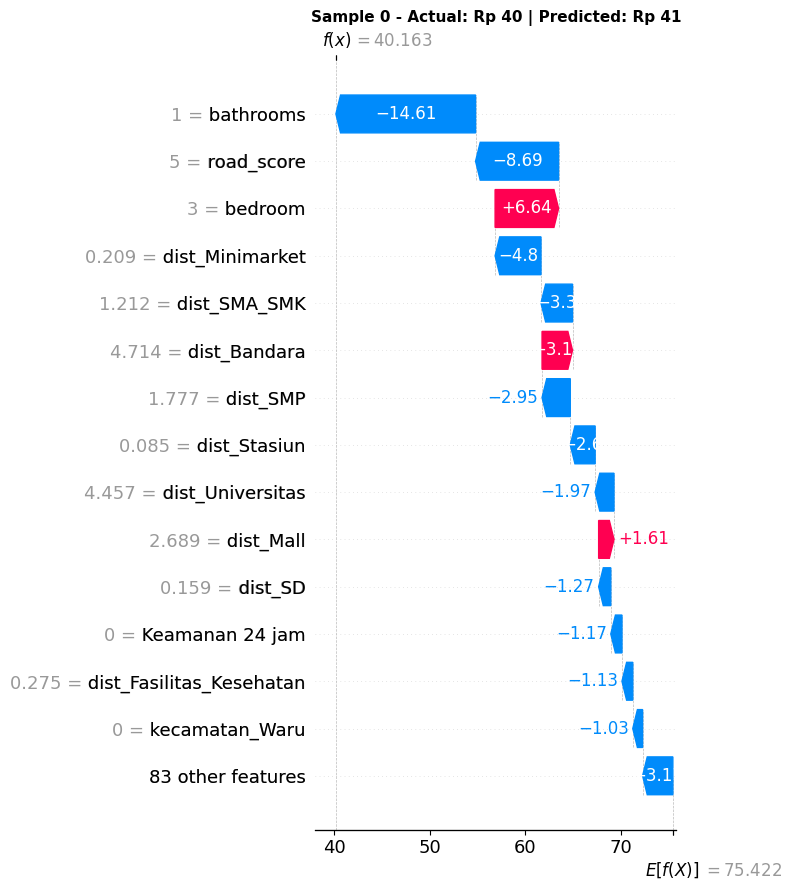

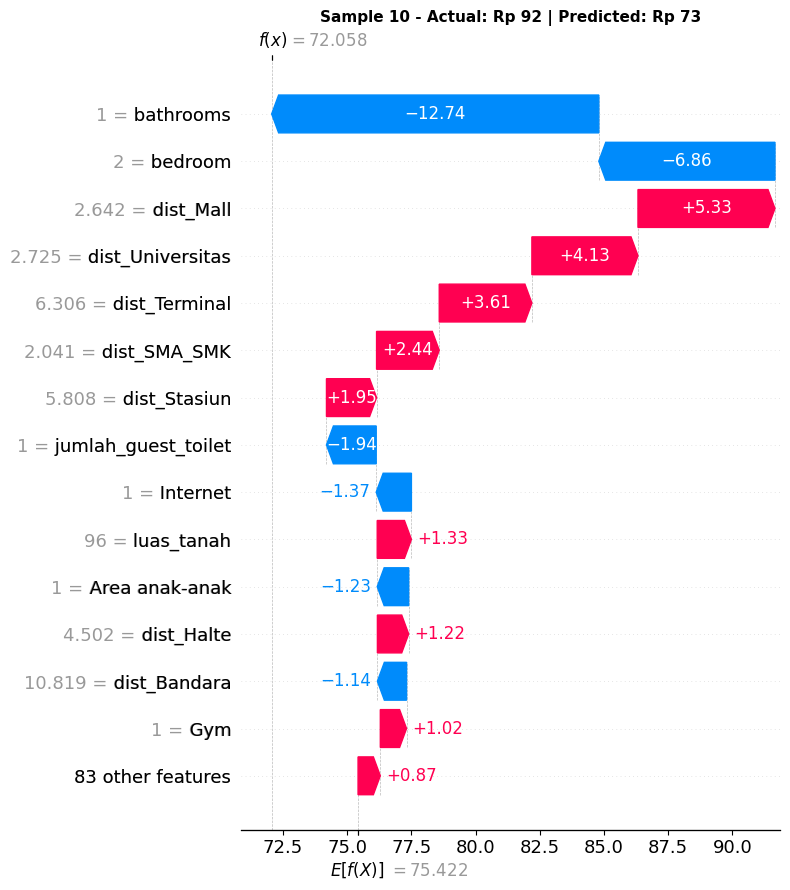

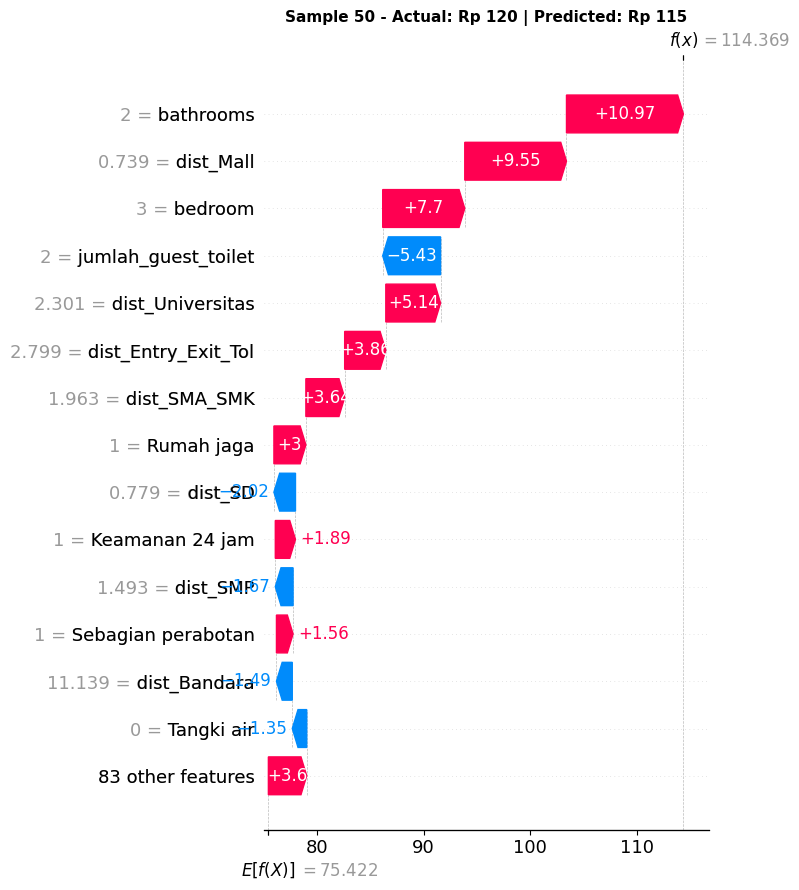

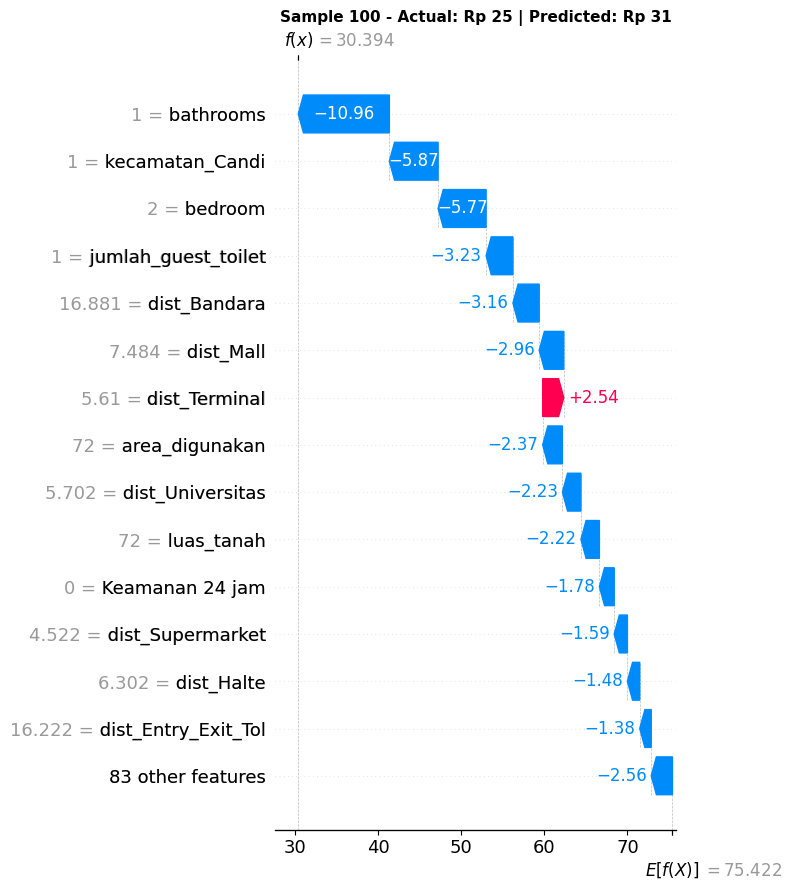

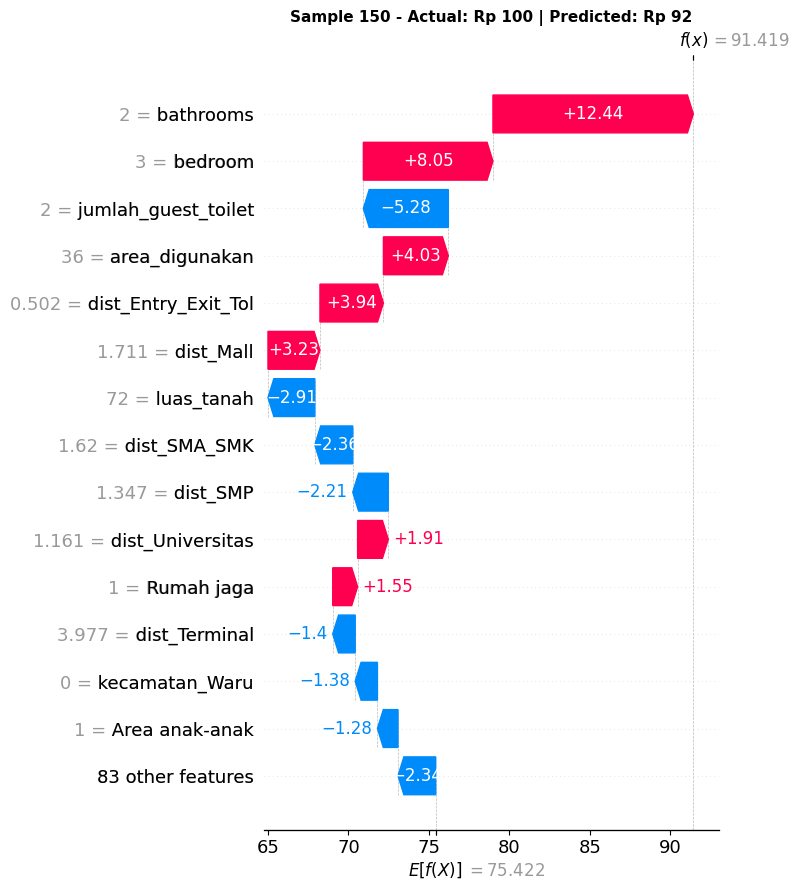

In [48]:
# SHAP Waterfall Plot - Output satu per satu (5 sampel) - CatBoost
if shap_values_cb_original is not None and expected_value_cb_original is not None:
    
    sample_idx = [0, 10, 50, 100, 150]  # 5 contoh
    
    for idx in sample_idx:
        if idx < len(X_shap_sample):
            
            plt.figure(figsize=(10, 6))  # Buat figure baru tiap loop
            
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_cb_original[idx],
                    base_values=float(expected_value_cb_original),
                    data=X_shap_sample.iloc[idx].values,
                    feature_names=feature_names_cb
                ),
                max_display=15,
                show=False
            )
            
            actual_price = y_shap_sample_original[idx]
            predicted_price = train_pred_cb_original[idx]
            
            plt.title(
                f"Sample {idx} - Actual: Rp {actual_price:,.0f} | Predicted: Rp {predicted_price:,.0f}",
                fontsize=11,
                fontweight="bold"
            )
            
            plt.tight_layout()
            plt.show()  # tampilkan satu-satu

else:
    print("⚠ SHAP values not available. Skipping waterfall plots.")

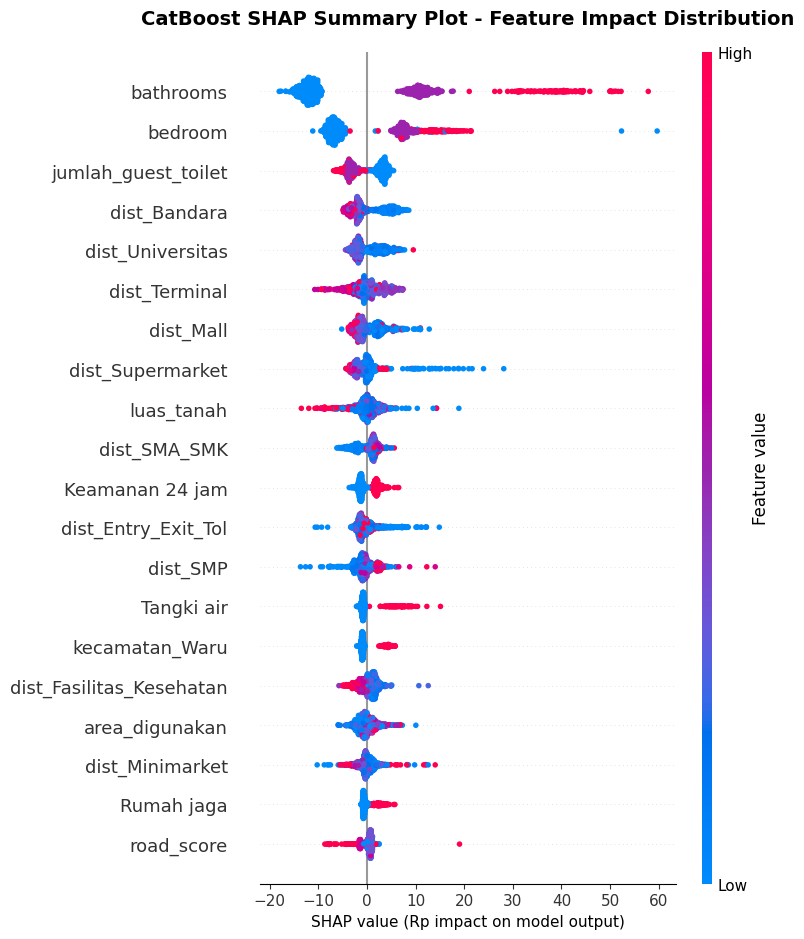

In [49]:
# SHAP Summary Plot - Beeswarm (Feature Impact Distribution) - CatBoost
if shap_values_cb_original is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_cb_original, X_shap_sample, feature_names=feature_names_cb, max_display=20, show=False)
    plt.title('CatBoost SHAP Summary Plot - Feature Impact Distribution', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('SHAP value (Rp impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping beeswarm plot.")


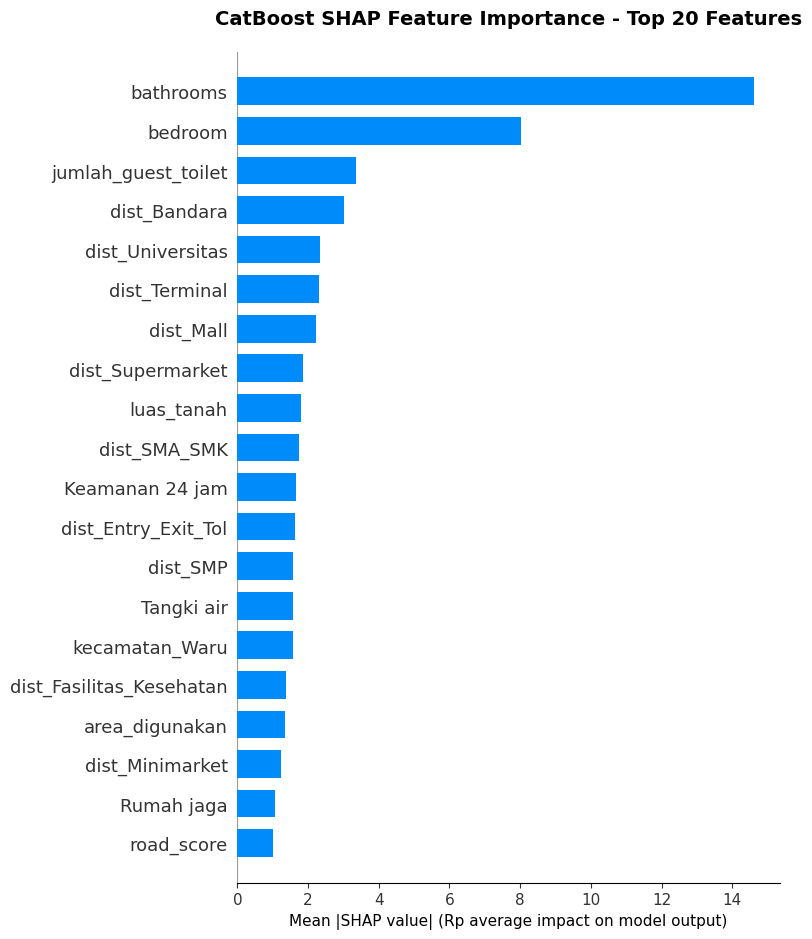

In [50]:
# SHAP Summary Plot - Bar (Feature Importance) - CatBoost
if shap_values_cb_original is not None:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_cb_original, X_shap_sample, feature_names=feature_names_cb, plot_type="bar", max_display=20, show=False)
    plt.title('CatBoost SHAP Feature Importance - Top 20 Features', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Mean |SHAP value| (Rp average impact on model output)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ SHAP values not available. Skipping bar plot.")
